# 04 — Light-M: final multi-scale training notebook

This notebook trains **Light-M**, the main proposed model of the project.

- **encoder:** ImageNet-pretrained MobileNetV2;
- **features used:** `s4`, `s8`, `s16`, and `s32`;
- **decoder:** compact top-down multi-scale decoder with additive skip fusion;
- **input:** RGB image `[B, 3, 169, 256]`;
- **output:** raw saliency logits `[B, 1, 169, 256]`;
- **objective:** KLD plus correlation loss;
- **checkpoint rule:** highest validation CC.

The experiment keeps the Light-S protocol unchanged. Therefore, the controlled comparison

```text
Light-S  versus  Light-M
```

isolates the effect of multi-scale feature fusion under the same MobileNetV2 encoder.

The internal test split is not used here.


## Execution plan

Run the notebook from top to bottom in a **GPU Colab runtime**.

```text
Drive + GitHub setup
→ restore the existing local SALICON cache
→ localize and verify manifests
→ build datasets and loaders
→ verify all four feature scales and skip gradients
→ tiny-batch overfit check
→ three-epoch pilot
→ resume final training to at most 15 epochs
→ load the best checkpoint
→ save validation metrics, predictions, curves, and comparison files
```

The persistent archive already created by the Light-S notebook is reused. This notebook does **not** rebuild the archive from thousands of Drive files.


## 1. Mount Google Drive

Drive stores the persistent dataset archive, checkpoints, CSV files, figures, and experiment logs.


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 2. Clone or update the GitHub repository

The repository under `/content` is temporary. A fresh runtime clones it; an existing clean clone is updated with a fast-forward pull.


In [2]:
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/RicoDalB/efficient-saliency-prediction.git"
REPO_ROOT = Path("/content/efficient-saliency-prediction")

if not REPO_ROOT.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_ROOT)],
        check=True,
    )
else:
    pull_result = subprocess.run(
        [
            "git",
            "-C",
            str(REPO_ROOT),
            "pull",
            "--ff-only",
            "origin",
            "main",
        ],
        capture_output=True,
        text=True,
    )

    print(pull_result.stdout)

    if pull_result.returncode != 0:
        print(pull_result.stderr)
        raise RuntimeError(
            "Git pull failed. Restart the runtime or remove local changes "
            "from the temporary clone."
        )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository:", REPO_ROOT)


Repository: /content/efficient-saliency-prediction


## 3. Define persistent project paths

All model-specific artifacts use the stable name `light_multi`. This prevents accidental overwriting of Light-S outputs.


In [3]:
DRIVE_ROOT = Path("/content/drive/MyDrive/saliency_project")
DRIVE_DATA_ROOT = DRIVE_ROOT / "data" / "SALICON"

CHECKPOINT_ROOT = DRIVE_ROOT / "checkpoints"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"
METRICS_ROOT = OUTPUT_ROOT / "metrics"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
LOG_ROOT = DRIVE_ROOT / "logs"

TRAIN_MANIFEST_PATH = REPO_ROOT / "splits" / "train_manifest.csv"
VAL_MANIFEST_PATH = REPO_ROOT / "splits" / "val_manifest.csv"

MODEL_NAME = "light_multi"
LIGHT_MULTI_CHECKPOINT_DIR = CHECKPOINT_ROOT / MODEL_NAME

LIGHT_MULTI_HISTORY_PATH = METRICS_ROOT / "light_multi_history.csv"
LIGHT_MULTI_TRAINING_SUMMARY_PATH = METRICS_ROOT / "light_multi_training_summary.csv"
LIGHT_MULTI_VAL_SUMMARY_PATH = METRICS_ROOT / "light_multi_validation_summary.csv"
LIGHT_MULTI_VAL_PER_IMAGE_PATH = METRICS_ROOT / "light_multi_validation_per_image.csv"
LIGHT_MULTI_CONFIG_PATH = METRICS_ROOT / "light_multi_config.json"

LIGHT_MULTI_CURVES_PATH = FIGURE_ROOT / "training_curves_light_multi.png"
LIGHT_MULTI_PREVIEW_PATH = FIGURE_ROOT / "validation_preview_light_multi.png"
LIGHT_MULTI_BEST_PREVIEW_PATH = FIGURE_ROOT / "best_validation_preview_light_multi.png"
LIGHT_MULTI_TINY_OVERFIT_PATH = FIGURE_ROOT / "tiny_overfit_light_multi.png"

LIGHT_COMPARISON_CSV_PATH = METRICS_ROOT / "light_single_vs_light_multi_validation.csv"
LIGHT_COMPARISON_FIGURE_PATH = FIGURE_ROOT / "light_single_vs_light_multi_history.png"

for directory in [
    LIGHT_MULTI_CHECKPOINT_DIR,
    METRICS_ROOT,
    FIGURE_ROOT,
    LOG_ROOT / "run_notes",
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Checkpoint directory:", LIGHT_MULTI_CHECKPOINT_DIR)
print("Metrics directory:   ", METRICS_ROOT)
print("Figures directory:   ", FIGURE_ROOT)


Checkpoint directory: /content/drive/MyDrive/saliency_project/checkpoints/light_multi
Metrics directory:    /content/drive/MyDrive/saliency_project/outputs/metrics
Figures directory:    /content/drive/MyDrive/saliency_project/outputs/figures


## 4. Verify required source files and manifests

The notebook stops immediately when a shared module or fixed manifest is missing. Long training must never begin with incomplete project code.


In [4]:
required_paths = [
    REPO_ROOT / "src" / "data.py",
    REPO_ROOT / "src" / "losses_metrics.py",
    REPO_ROOT / "src" / "models.py",
    REPO_ROOT / "src" / "train_eval.py",
    TRAIN_MANIFEST_PATH,
    VAL_MANIFEST_PATH,
    DRIVE_DATA_ROOT / "images",
    DRIVE_DATA_ROOT / "maps",
]

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    formatted = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Required project paths are missing:\n{formatted}")

print("All required project paths exist.")


All required project paths exist.


## 5. Import and reload the shared project modules

`importlib.reload` ensures that Colab uses the files just pulled from GitHub rather than an older cached module.


In [5]:
import importlib
import inspect
import json
import random
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import src.data
import src.losses_metrics
import src.models
import src.train_eval

importlib.invalidate_caches()
importlib.reload(src.data)
importlib.reload(src.losses_metrics)
importlib.reload(src.models)
importlib.reload(src.train_eval)

from src.data import SaliconDataset, build_dataloader
from src.losses_metrics import saliency_loss, spatial_softmax, validate_spatial_distribution
from src.models import build_model, parameter_summary
from src.train_eval import (
    build_optimizer,
    evaluate_model,
    fit_model,
    load_checkpoint,
    plot_prediction_panel,
    plot_training_history,
)

print("Shared project modules imported successfully.")


Shared project modules imported successfully.


## 6. Check the shared APIs before doing expensive work

This cell catches placeholder or outdated `.py` files before the dataset archive is copied and before a GPU training run starts.


In [6]:
required_model_functions = ["build_model", "parameter_summary"]
required_training_functions = [
    "build_optimizer",
    "evaluate_model",
    "fit_model",
    "load_checkpoint",
    "plot_prediction_panel",
    "plot_training_history",
]

missing_model_functions = [
    name for name in required_model_functions if not hasattr(src.models, name)
]
missing_training_functions = [
    name for name in required_training_functions if not hasattr(src.train_eval, name)
]

if missing_model_functions or missing_training_functions:
    raise ImportError(
        "The shared source files are incomplete. "
        f"Missing model functions: {missing_model_functions}; "
        f"missing training functions: {missing_training_functions}. "
        "Push the complete .py files to GitHub, then restart this notebook."
    )

# Build and execute a tiny CPU Light-M forward pass before copying the dataset archive.
api_probe_model = build_model(
    "light_multi",
    pretrained=False,
    decoder_channels=8,
)
api_probe_model.eval()

if not hasattr(api_probe_model.decoder, "_upsample_add"):
    raise AttributeError(
        "MultiScaleDecoder must define _upsample_add(). "
        "Check for a spelling mismatch such as _unsample_add in src/models.py."
    )

with torch.inference_mode():
    api_probe_output = api_probe_model(torch.zeros(1, 3, 64, 96))

if api_probe_output.shape != (1, 1, 64, 96):
    raise RuntimeError(
        f"Unexpected Light-M probe shape: {tuple(api_probe_output.shape)}"
    )

del api_probe_model, api_probe_output

print("build_optimizer:", inspect.signature(build_optimizer))
print("evaluate_model: ", inspect.signature(evaluate_model))
print("fit_model:      ", inspect.signature(fit_model))


build_optimizer: (model: 'nn.Module', *, encoder_lr: 'float' = 0.0001, decoder_lr: 'float' = 0.0003, weight_decay: 'float' = 0.0001) -> 'AdamW'
evaluate_model:  (model: 'nn.Module', dataloader: 'DataLoader', device: 'torch.device', *, use_amp: 'bool' = True, return_per_image: 'bool' = False) -> 'tuple[dict[str, float], list[dict[str, Any]]]'
fit_model:       (model: 'nn.Module', train_loader: 'DataLoader', val_loader: 'DataLoader', optimizer: 'Optimizer', device: 'torch.device', *, model_name: 'str', epochs: 'int', checkpoint_dir: 'str | Path', history_csv_path: 'str | Path', curves_figure_path: 'str | Path', preview_batch: 'Mapping[str, Any] | None' = None, preview_figure_path: 'str | Path | None' = None, config: 'Mapping[str, Any] | None' = None, split_seed: 'int' = 42, repo_root: 'str | Path | None' = None, patience: 'int' = 3, min_delta: 'float' = 0.0001, freeze_encoder_epochs: 'int' = 1, freeze_encoder_batchnorm: 'bool' = True, use_amp: 'bool' = True, gradient_clip_norm: 'float | 

## 7. Set the seed, device, and fair-comparison configuration

These values match the Light-S run. The architecture is the only intended experimental change.


In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_SIZE = (169, 256)  # (height, width), identical to Light-S
DECODER_CHANNELS = 32

BATCH_SIZE = 8
NUM_WORKERS = 2

RUN_TINY_OVERFIT = True
TINY_OVERFIT_STEPS = 30

PILOT_EPOCHS = 3
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3

ENCODER_LR = 1e-4
DECODER_LR = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

if DEVICE.type != "cuda":
    raise RuntimeError(
        "A CUDA GPU is required for practical training time. "
        "In Colab select Runtime > Change runtime type > GPU."
    )

print("Device:       ", DEVICE)
print("PyTorch:      ", torch.__version__)
print("CUDA:         ", torch.version.cuda)
print("GPU:          ", torch.cuda.get_device_name(0))
print("Output size:  ", OUTPUT_SIZE)
print("Batch size:   ", BATCH_SIZE)
print("Data workers: ", NUM_WORKERS)


Device:        cuda
PyTorch:       2.11.0+cu128
CUDA:          12.8
GPU:           Tesla T4
Output size:   (169, 256)
Batch size:    8
Data workers:  2


## 8. Define the existing SALICON archive and local-cache paths

The persistent TAR is the source used to rebuild the temporary cache in a new runtime.


In [8]:
SALICON_ARCHIVE_DRIVE = DRIVE_ROOT / "backups" / "salicon_images_maps.tar"

LOCAL_CACHE_ROOT = Path("/content/saliency_cache")
LOCAL_DATA_ROOT = LOCAL_CACHE_ROOT / "SALICON"
LOCAL_IMAGE_ROOT = LOCAL_DATA_ROOT / "images"
LOCAL_MAP_ROOT = LOCAL_DATA_ROOT / "maps"
CACHE_READY_MARKER = LOCAL_DATA_ROOT / ".cache_ready"

LOCAL_ARCHIVE_PATH = Path("/content/salicon_images_maps.tar")

EXPECTED_IMAGE_FILES = 20_000
EXPECTED_MAP_FILES = 15_000

print("Persistent archive:", SALICON_ARCHIVE_DRIVE)
print("Local cache root:  ", LOCAL_DATA_ROOT)


Persistent archive: /content/drive/MyDrive/saliency_project/backups/salicon_images_maps.tar
Local cache root:   /content/saliency_cache/SALICON


## 9. Inspect temporary disk space and current cache status

A new runtime normally has no extracted cache. The persistent archive remains in Drive.


In [9]:
def print_local_disk_space() -> None:
    total, used, free = shutil.disk_usage("/content")
    print(f"Local disk total: {total / (1024 ** 3):.2f} GB")
    print(f"Local disk used:  {used / (1024 ** 3):.2f} GB")
    print(f"Local disk free:  {free / (1024 ** 3):.2f} GB")


def local_cache_has_required_structure() -> bool:
    return (
        CACHE_READY_MARKER.is_file()
        and LOCAL_IMAGE_ROOT.is_dir()
        and LOCAL_MAP_ROOT.is_dir()
    )


print_local_disk_space()
print("Archive exists:    ", SALICON_ARCHIVE_DRIVE.is_file())
print("Local cache ready: ", local_cache_has_required_structure())


Local disk total: 112.64 GB
Local disk used:  46.77 GB
Local disk free:  65.85 GB
Archive exists:     True
Local cache ready:  False


## 10. Restore the local cache from the persistent TAR when needed

Only one large file is copied from Drive. The temporary local TAR is deleted immediately after successful extraction.


In [10]:
def restore_local_cache_from_archive() -> None:
    if not SALICON_ARCHIVE_DRIVE.is_file():
        raise FileNotFoundError(
            "The persistent SALICON archive is missing. Expected: "
            f"{SALICON_ARCHIVE_DRIVE}. Run the completed Light-S cache setup "
            "or recreate the archive before training Light-M."
        )

    archive_size_gb = SALICON_ARCHIVE_DRIVE.stat().st_size / (1024 ** 3)
    print(f"Copying persistent archive ({archive_size_gb:.2f} GB) to local disk...")

    LOCAL_ARCHIVE_PATH.unlink(missing_ok=True)
    shutil.copy2(SALICON_ARCHIVE_DRIVE, LOCAL_ARCHIVE_PATH)

    if LOCAL_CACHE_ROOT.exists():
        shutil.rmtree(LOCAL_CACHE_ROOT)
    LOCAL_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

    print("Extracting images and maps...")
    extraction = subprocess.run(
        [
            "tar",
            "-xf",
            str(LOCAL_ARCHIVE_PATH),
            "-C",
            str(LOCAL_CACHE_ROOT),
        ],
        capture_output=True,
        text=True,
    )

    if extraction.returncode != 0:
        raise RuntimeError(
            "SALICON archive extraction failed.\n\n"
            f"STDOUT:\n{extraction.stdout}\n\n"
            f"STDERR:\n{extraction.stderr}"
        )

    LOCAL_ARCHIVE_PATH.unlink(missing_ok=True)

    if not LOCAL_IMAGE_ROOT.is_dir() or not LOCAL_MAP_ROOT.is_dir():
        raise RuntimeError("The extracted cache is missing images/ or maps/.")

    CACHE_READY_MARKER.touch()
    print("Local SALICON cache restored.")


## 11. Reuse or restore the cache

Within the same runtime, the existing verified cache is reused without another copy or extraction.


In [11]:
if local_cache_has_required_structure():
    print("Local SALICON cache is already available; extraction skipped.")
else:
    restore_local_cache_from_archive()

if not local_cache_has_required_structure():
    raise RuntimeError("The local SALICON cache is not ready.")

TRAINING_DATA_ROOT = LOCAL_DATA_ROOT

print("Training data root:", TRAINING_DATA_ROOT)
print_local_disk_space()


Copying persistent archive (2.57 GB) to local disk...
Extracting images and maps...
Local SALICON cache restored.
Training data root: /content/saliency_cache/SALICON
Local disk total: 112.64 GB
Local disk used:  51.96 GB
Local disk free:  60.67 GB


## 12. Verify the complete extracted dataset

Exact file counts detect an interrupted or partial extraction before manifest localization and training.


In [12]:
def count_regular_files(root: Path) -> int:
    return sum(1 for path in root.rglob("*") if path.is_file())


image_file_count = count_regular_files(LOCAL_IMAGE_ROOT)
map_file_count = count_regular_files(LOCAL_MAP_ROOT)

print(f"Images: {image_file_count:,}")
print(f"Maps:   {map_file_count:,}")

if image_file_count != EXPECTED_IMAGE_FILES:
    raise RuntimeError(
        f"Expected {EXPECTED_IMAGE_FILES:,} image files, found {image_file_count:,}."
    )

if map_file_count != EXPECTED_MAP_FILES:
    raise RuntimeError(
        f"Expected {EXPECTED_MAP_FILES:,} map files, found {map_file_count:,}."
    )

print("Local dataset file counts are correct.")


Images: 20,000
Maps:   15,000
Local dataset file counts are correct.


## 13. Create local manifest copies

The version-controlled CSV files remain unchanged. Temporary copies under `/content` are rewritten so every image and map path is relative to the local SALICON root.


In [13]:
LOCAL_MANIFEST_ROOT = Path("/content/saliency_manifests")
LOCAL_MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)

LOCAL_TRAIN_MANIFEST_PATH = LOCAL_MANIFEST_ROOT / "train_manifest_local.csv"
LOCAL_VAL_MANIFEST_PATH = LOCAL_MANIFEST_ROOT / "val_manifest_local.csv"

IMAGE_COLUMN = "image_relpath"
MAP_COLUMN = "map_relpath"
ID_COLUMN = "sample_id"


def salicon_relative_path(value: object, expected_folder: str) -> str:
    text = str(value).replace("\\", "/").strip()

    # Remove everything before the canonical folder name.
    direct_prefix = f"{expected_folder}/"
    slash_prefix = f"/{expected_folder}/"

    if text.startswith(direct_prefix):
        return text

    position = text.find(slash_prefix)
    if position >= 0:
        return text[position + 1:]

    salicon_marker = "/SALICON/"
    position = text.find(salicon_marker)
    if position >= 0:
        candidate = text[position + len(salicon_marker):]
        if candidate.startswith(direct_prefix):
            return candidate

    raise ValueError(
        f"Could not convert path to a SALICON-relative {expected_folder} path: {value!r}"
    )


def create_local_manifest(source_path: Path, destination_path: Path) -> None:
    frame = pd.read_csv(source_path)

    required_columns = {IMAGE_COLUMN, MAP_COLUMN, ID_COLUMN}
    missing_columns = required_columns.difference(frame.columns)
    if missing_columns:
        raise ValueError(
            f"Manifest {source_path} is missing columns: {sorted(missing_columns)}"
        )

    frame[IMAGE_COLUMN] = frame[IMAGE_COLUMN].map(
        lambda value: salicon_relative_path(value, "images")
    )
    frame[MAP_COLUMN] = frame[MAP_COLUMN].map(
        lambda value: salicon_relative_path(value, "maps")
    )

    missing_examples = []
    for row in frame.itertuples(index=False):
        image_path = TRAINING_DATA_ROOT / getattr(row, IMAGE_COLUMN)
        map_path = TRAINING_DATA_ROOT / getattr(row, MAP_COLUMN)

        if not image_path.is_file() or not map_path.is_file():
            missing_examples.append(
                {
                    "sample_id": str(getattr(row, ID_COLUMN)),
                    "image": str(image_path),
                    "map": str(map_path),
                }
            )
            if len(missing_examples) >= 10:
                break

    if missing_examples:
        raise FileNotFoundError(
            "Localized manifest contains missing files. Examples:\n"
            + json.dumps(missing_examples, indent=2)
        )

    frame.to_csv(destination_path, index=False)
    print(f"Saved {len(frame):,} verified rows -> {destination_path}")


## 14. Localize both fixed manifests

Training and validation continue to use the exact sample IDs already fixed by the project split.


In [14]:
create_local_manifest(TRAIN_MANIFEST_PATH, LOCAL_TRAIN_MANIFEST_PATH)
create_local_manifest(VAL_MANIFEST_PATH, LOCAL_VAL_MANIFEST_PATH)


Saved 10,000 verified rows -> /content/saliency_manifests/train_manifest_local.csv
Saved 2,500 verified rows -> /content/saliency_manifests/val_manifest_local.csv


## 15. Inspect the localized manifests

A small table confirms that the paths now begin with `images/` and `maps/` and that sample IDs remain unchanged.


In [15]:
localized_train_frame = pd.read_csv(LOCAL_TRAIN_MANIFEST_PATH)
localized_val_frame = pd.read_csv(LOCAL_VAL_MANIFEST_PATH)

print("Training rows:  ", len(localized_train_frame))
print("Validation rows:", len(localized_val_frame))

display(localized_train_frame[[ID_COLUMN, IMAGE_COLUMN, MAP_COLUMN]].head())


Training rows:   10000
Validation rows: 2500


,sample_id,image_relpath,map_relpath
0,100273,images/images/train/COCO_train2014_00000010027...,maps/train/COCO_train2014_000000100273.png
1,100282,images/images/train/COCO_train2014_00000010028...,maps/train/COCO_train2014_000000100282.png
2,100303,images/images/train/COCO_train2014_00000010030...,maps/train/COCO_train2014_000000100303.png
3,100311,images/images/train/COCO_train2014_00000010031...,maps/train/COCO_train2014_000000100311.png
4,100319,images/images/train/COCO_train2014_00000010031...,maps/train/COCO_train2014_000000100319.png


## 16. Build the training dataset

The RGB image is ImageNet-normalized. The continuous target map is resized and normalized to one spatial distribution by `src/data.py`.


In [16]:
train_dataset = SaliconDataset(
    manifest_path=LOCAL_TRAIN_MANIFEST_PATH,
    data_root=TRAINING_DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=OUTPUT_SIZE,
    use_imagenet_normalization=True,
)

print("Training samples:", len(train_dataset))


Training samples: 10000


## 17. Build the validation dataset

Validation uses the same preprocessing but never shuffles sample order.


In [17]:
val_dataset = SaliconDataset(
    manifest_path=LOCAL_VAL_MANIFEST_PATH,
    data_root=TRAINING_DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=OUTPUT_SIZE,
    use_imagenet_normalization=True,
)

print("Validation samples:", len(val_dataset))


Validation samples: 2500


## 18. Build deterministic DataLoaders

The selected settings match Light-S. Local caching is activated before worker tuning, so the GPU does not repeatedly wait for mounted Drive reads.


In [18]:
train_loader = build_dataloader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

val_loader = build_dataloader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

print("Training batches:  ", len(train_loader))
print("Validation batches:", len(val_loader))


Training batches:   1250
Validation batches: 313


## 19. Measure local loading speed

The first batch includes worker startup. The average across several batches gives a more useful loading estimate.


In [19]:
TIMING_BATCHES = min(20, len(train_loader))

timing_iterator = iter(train_loader)
loading_start = time.perf_counter()

for _ in range(TIMING_BATCHES):
    next(timing_iterator)

loading_seconds = time.perf_counter() - loading_start

print(f"Measured batches:       {TIMING_BATCHES}")
print(f"Total loading time:     {loading_seconds:.2f} s")
print(f"Average time per batch: {loading_seconds / TIMING_BATCHES:.3f} s")


Measured batches:       20
Total loading time:     1.69 s
Average time per batch: 0.084 s


## 20. Keep one fixed validation batch

The same examples are used for every epoch preview, making visual training progress comparable over time.


In [20]:
preview_batch = next(iter(val_loader))

preview_images = preview_batch["image"]
preview_targets = preview_batch["target"]
preview_ids = preview_batch["sample_id"]

validate_spatial_distribution(preview_targets, name="validation targets")

print("Image batch shape: ", tuple(preview_images.shape))
print("Target batch shape:", tuple(preview_targets.shape))
print("First sample IDs:  ", list(preview_ids)[:4])
print("Target masses:     ", preview_targets.flatten(1).sum(dim=1)[:4])


Image batch shape:  (8, 3, 169, 256)
Target batch shape: (8, 1, 169, 256)
First sample IDs:   ['1000', '100000', '100081', '100187']
Target masses:      tensor([1., 1., 1., 1.])


## 21. Build Light-M and inspect parameter counts

Light-M keeps the same MobileNetV2 encoder as Light-S. The extra parameters belong only to the compact multi-scale projections and refinement path.


In [21]:
architecture_model = build_model(
    MODEL_NAME,
    pretrained=True,
    decoder_channels=DECODER_CHANNELS,
).to(DEVICE)

architecture_counts = parameter_summary(architecture_model)

print("Encoder class: ", architecture_model.encoder.__class__.__name__)
print("Decoder class: ", architecture_model.decoder.__class__.__name__)
print("Encoder params:", f"{architecture_counts['encoder']:,}")
print("Decoder params:", f"{architecture_counts['decoder']:,}")
print("Total params:  ", f"{architecture_counts['total']:,}")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 230MB/s]

Encoder class:  MobileNetV2Encoder
Decoder class:  MultiScaleDecoder
Encoder params: 1,811,712
Decoder params: 19,265
Total params:   1,830,977


## 22. Verify all four MobileNetV2 feature scales

For the project input size, spatial dimensions are not exact powers of two because the height is odd. The decoder therefore resizes to the actual lateral-feature shape rather than assuming a fixed scale factor.


In [22]:
architecture_model.eval()
architecture_images = preview_images[:1].to(DEVICE)

with torch.inference_mode():
    architecture_features = architecture_model.encoder(architecture_images)

expected_keys = {"s4", "s8", "s16", "s32"}

if set(architecture_features) != expected_keys:
    raise RuntimeError(
        f"Expected feature keys {sorted(expected_keys)}, "
        f"received {sorted(architecture_features)}"
    )

feature_rows = []
for key in ["s4", "s8", "s16", "s32"]:
    tensor = architecture_features[key]
    feature_rows.append(
        {
            "feature": key,
            "shape": str(tuple(tensor.shape)),
            "channels": int(tensor.shape[1]),
            "height": int(tensor.shape[2]),
            "width": int(tensor.shape[3]),
        }
    )

display(pd.DataFrame(feature_rows))


,feature,shape,channels,height,width
0,s4,"(1, 24, 43, 64)",24,43,64
1,s8,"(1, 32, 22, 32)",32,22,32
2,s16,"(1, 96, 11, 16)",96,11,16
3,s32,"(1, 320, 6, 8)",320,6,8


## 23. Verify output, probability mass, loss, and skip-path gradients

A successful Light-M check requires gradients not only in the encoder and prediction head, but also in every lateral projection: `s4`, `s8`, `s16`, and `s32`.


In [23]:
architecture_model.train()
architecture_model.zero_grad(set_to_none=True)

sanity_images = preview_images[:2].to(DEVICE)
sanity_targets = preview_targets[:2].to(DEVICE)

sanity_logits = architecture_model(sanity_images)
sanity_prediction = spatial_softmax(sanity_logits)
sanity_loss = saliency_loss(sanity_logits, sanity_targets)

validate_spatial_distribution(sanity_prediction, name="Light-M prediction")

if sanity_logits.shape != sanity_targets.shape:
    raise ValueError(
        f"Output/target mismatch: {tuple(sanity_logits.shape)} "
        f"versus {tuple(sanity_targets.shape)}"
    )

if not torch.isfinite(sanity_loss).item():
    raise FloatingPointError("The Light-M sanity loss is not finite.")

sanity_loss.backward()

encoder_has_gradient = any(
    parameter.grad is not None and torch.isfinite(parameter.grad).all().item()
    for parameter in architecture_model.encoder.parameters()
    if parameter.requires_grad
)

decoder_has_gradient = any(
    parameter.grad is not None and torch.isfinite(parameter.grad).all().item()
    for parameter in architecture_model.decoder.parameters()
    if parameter.requires_grad
)

projection_gradient_rows = []
for key, projection in architecture_model.decoder.projections.items():
    gradient_norm = sum(
        float(parameter.grad.detach().norm().cpu())
        for parameter in projection.parameters()
        if parameter.grad is not None
    )
    projection_gradient_rows.append(
        {"projection": key, "gradient_norm": gradient_norm}
    )

projection_gradient_frame = pd.DataFrame(projection_gradient_rows)

if not encoder_has_gradient or not decoder_has_gradient:
    raise RuntimeError("Gradients did not reach both encoder and decoder.")

if (projection_gradient_frame["gradient_norm"] <= 0).any():
    raise RuntimeError(
        "At least one multi-scale projection received no gradient:\n"
        + projection_gradient_frame.to_string(index=False)
    )

print("Output shape:     ", tuple(sanity_logits.shape))
print("Finite loss:      ", float(sanity_loss.detach().cpu()))
print("Prediction masses:", sanity_prediction.flatten(1).sum(dim=1).detach().cpu())
print("Encoder gradient: ", encoder_has_gradient)
print("Decoder gradient: ", decoder_has_gradient)

display(projection_gradient_frame)
print("Light-M multi-scale sanity check passed.")


Output shape:      (2, 1, 169, 256)
Finite loss:       1.7981127500534058
Prediction masses: tensor([1.0000, 1.0000])
Encoder gradient:  True
Decoder gradient:  True


,projection,gradient_norm
0,s4,0.728255
1,s8,0.147729
2,s16,0.038176
3,s32,0.035757


Light-M multi-scale sanity check passed.


## 24. Release architecture-check tensors

The diagnostic model is no longer needed. Releasing it avoids carrying unnecessary GPU memory into the tiny overfit and full training runs.


In [24]:
del (
    architecture_model,
    architecture_images,
    architecture_features,
    sanity_images,
    sanity_targets,
    sanity_logits,
    sanity_prediction,
    sanity_loss,
)

torch.cuda.empty_cache()


## 25. Tiny-batch overfit check

This short optimization test confirms that the complete Light-M pipeline can reduce loss on a fixed group of real SALICON examples. It is a diagnostic, not a reportable training run.


step 01/30 - loss: 1.9860
step 10/30 - loss: 1.1902
step 20/30 - loss: 0.6614
step 30/30 - loss: 0.3559


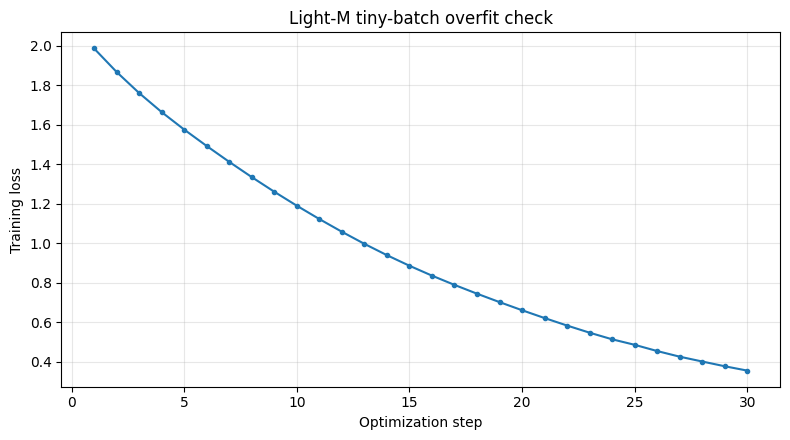

Initial loss: 1.9859694242477417
Final loss:   0.3559125065803528
Saved figure: /content/drive/MyDrive/saliency_project/outputs/figures/tiny_overfit_light_multi.png


In [25]:
if RUN_TINY_OVERFIT:
    tiny_model = build_model(
        MODEL_NAME,
        pretrained=True,
        decoder_channels=DECODER_CHANNELS,
    ).to(DEVICE)

    tiny_optimizer = torch.optim.AdamW(
        tiny_model.parameters(),
        lr=1e-3,
        weight_decay=0.0,
    )

    tiny_images = preview_images[:4].to(DEVICE)
    tiny_targets = preview_targets[:4].to(DEVICE)
    tiny_losses = []

    tiny_model.train()

    for step in range(TINY_OVERFIT_STEPS):
        tiny_optimizer.zero_grad(set_to_none=True)

        tiny_logits = tiny_model(tiny_images)
        tiny_loss = saliency_loss(tiny_logits, tiny_targets)
        tiny_loss.backward()
        tiny_optimizer.step()

        tiny_losses.append(float(tiny_loss.detach().cpu()))

        if step == 0 or (step + 1) % 10 == 0:
            print(
                f"step {step + 1:02d}/{TINY_OVERFIT_STEPS} "
                f"- loss: {tiny_losses[-1]:.4f}"
            )

    if min(tiny_losses[-5:]) >= tiny_losses[0]:
        raise RuntimeError(
            "The tiny-batch loss did not improve. Inspect the model, loss, "
            "targets, and learning rate before full training."
        )

    figure = plt.figure(figsize=(8, 4.5))
    plt.plot(range(1, len(tiny_losses) + 1), tiny_losses, marker="o", markersize=3)
    plt.xlabel("Optimization step")
    plt.ylabel("Training loss")
    plt.title("Light-M tiny-batch overfit check")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    figure.savefig(LIGHT_MULTI_TINY_OVERFIT_PATH, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(figure)

    print("Initial loss:", tiny_losses[0])
    print("Final loss:  ", tiny_losses[-1])
    print("Saved figure:", LIGHT_MULTI_TINY_OVERFIT_PATH)

    del tiny_model, tiny_optimizer, tiny_images, tiny_targets, tiny_logits, tiny_loss
    torch.cuda.empty_cache()
else:
    print("Tiny-batch overfit check skipped by configuration.")


## 26. Save the complete Light-M configuration

The explicit JSON file complements the configuration embedded inside each checkpoint and makes the experiment easy to inspect without loading PyTorch state.


In [26]:
light_multi_config = {
    "model_name": MODEL_NAME,
    "encoder_name": "MobileNetV2",
    "decoder_type": "multi_scale_additive",
    "feature_scales": ["s4", "s8", "s16", "s32"],
    "pretrained_encoder": True,
    "decoder_channels": DECODER_CHANNELS,
    "output_height": OUTPUT_SIZE[0],
    "output_width": OUTPUT_SIZE[1],
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "optimizer": "AdamW",
    "encoder_learning_rate": ENCODER_LR,
    "decoder_learning_rate": DECODER_LR,
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "freeze_encoder_epochs": 1,
    "freeze_encoder_batchnorm": True,
    "automatic_mixed_precision": True,
    "checkpoint_metric": "validation_cc",
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "minimum_cc_improvement": 1e-4,
    "pilot_epochs": PILOT_EPOCHS,
    "maximum_epochs": MAX_EPOCHS,
    "split_seed": SEED,
    "training_data_root": str(TRAINING_DATA_ROOT),
    "train_manifest": str(TRAIN_MANIFEST_PATH),
    "validation_manifest": str(VAL_MANIFEST_PATH),
    "persistent_archive": str(SALICON_ARCHIVE_DRIVE),
}

with LIGHT_MULTI_CONFIG_PATH.open("w", encoding="utf-8") as file:
    json.dump(light_multi_config, file, indent=2)

print("Saved configuration:", LIGHT_MULTI_CONFIG_PATH)


Saved configuration: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_config.json


## 27. Create a compatible model and two-rate optimizer

The shared optimizer creates separate parameter groups: a lower learning rate for the pretrained encoder and a higher learning rate for the new decoder.


In [27]:
def create_light_multi_experiment():
    model = build_model(
        MODEL_NAME,
        pretrained=True,
        decoder_channels=DECODER_CHANNELS,
    ).to(DEVICE)

    optimizer = build_optimizer(
        model,
        encoder_lr=ENCODER_LR,
        decoder_lr=DECODER_LR,
        weight_decay=WEIGHT_DECAY,
    )

    return model, optimizer


probe_model, probe_optimizer = create_light_multi_experiment()

for index, group in enumerate(probe_optimizer.param_groups):
    print(
        f"optimizer group {index}: "
        f"name={group.get('name', index)}, "
        f"lr={group['lr']:.1e}, parameters={len(group['params'])}"
    )

del probe_model, probe_optimizer
torch.cuda.empty_cache()


optimizer group 0: name=encoder, lr=1.0e-04, parameters=153
optimizer group 1: name=decoder, lr=3.0e-04, parameters=18


## 28. Define checkpoint paths and inspect resume status

`last.pt` supports interruption recovery. `best.pt` stores the epoch with the highest validation CC.


In [28]:
LAST_CHECKPOINT_PATH = LIGHT_MULTI_CHECKPOINT_DIR / "last.pt"
BEST_CHECKPOINT_PATH = LIGHT_MULTI_CHECKPOINT_DIR / "best.pt"

print("Best checkpoint exists:", BEST_CHECKPOINT_PATH.is_file())
print("Last checkpoint exists:", LAST_CHECKPOINT_PATH.is_file())

if LAST_CHECKPOINT_PATH.is_file():
    try:
        existing_checkpoint = torch.load(
            LAST_CHECKPOINT_PATH,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        existing_checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location="cpu")

    print("Existing last epoch:", existing_checkpoint.get("epoch"))
    print("Existing best CC:  ", existing_checkpoint.get("best_val_cc"))


Best checkpoint exists: False
Last checkpoint exists: False


## 29. Run or resume the three-epoch pilot

The pilot checks memory use, epoch duration, validation behavior, checkpoint saving, curve generation, and fixed qualitative previews on the full split.



light_multi | epoch 1/3 | encoder: frozen | AMP: True
Train loss: 0.5683 | Val loss: 0.3835 | Val KLD: 0.3011 | Val CC: 0.8360 | Val SIM: 0.7315
Epoch time: 2.34 min | Best val CC: 0.8360 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


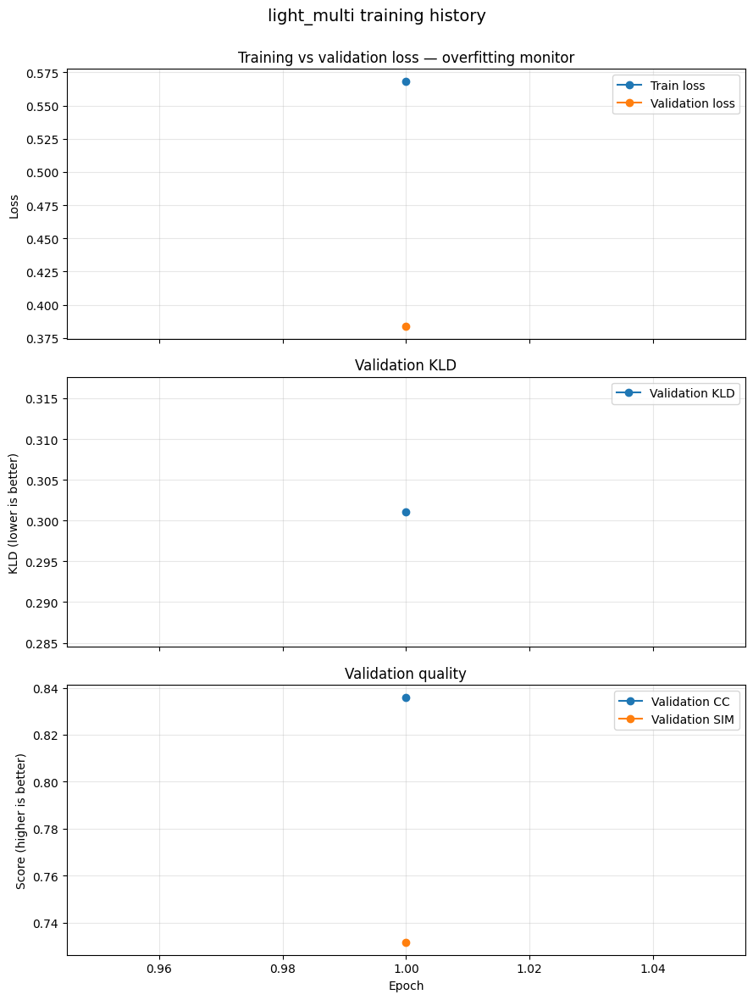

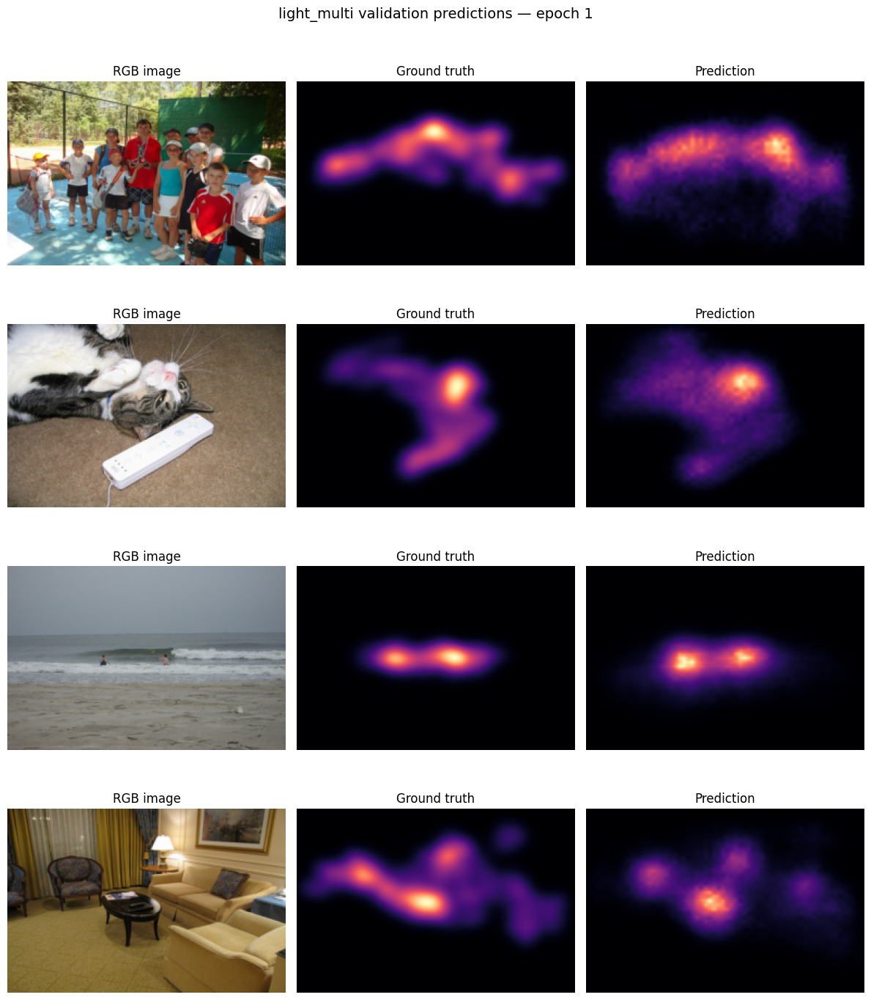


light_multi | epoch 2/3 | encoder: trainable | AMP: True
Train loss: 0.3584 | Val loss: 0.3124 | Val KLD: 0.2459 | Val CC: 0.8679 | Val SIM: 0.7600
Epoch time: 2.49 min | Best val CC: 0.8679 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


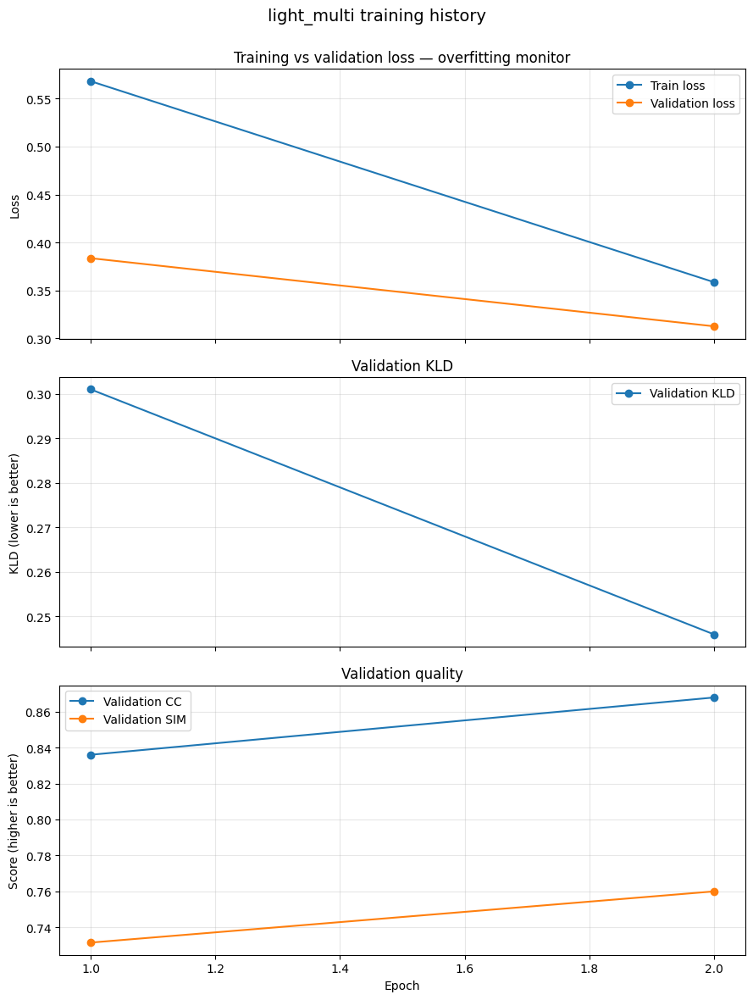

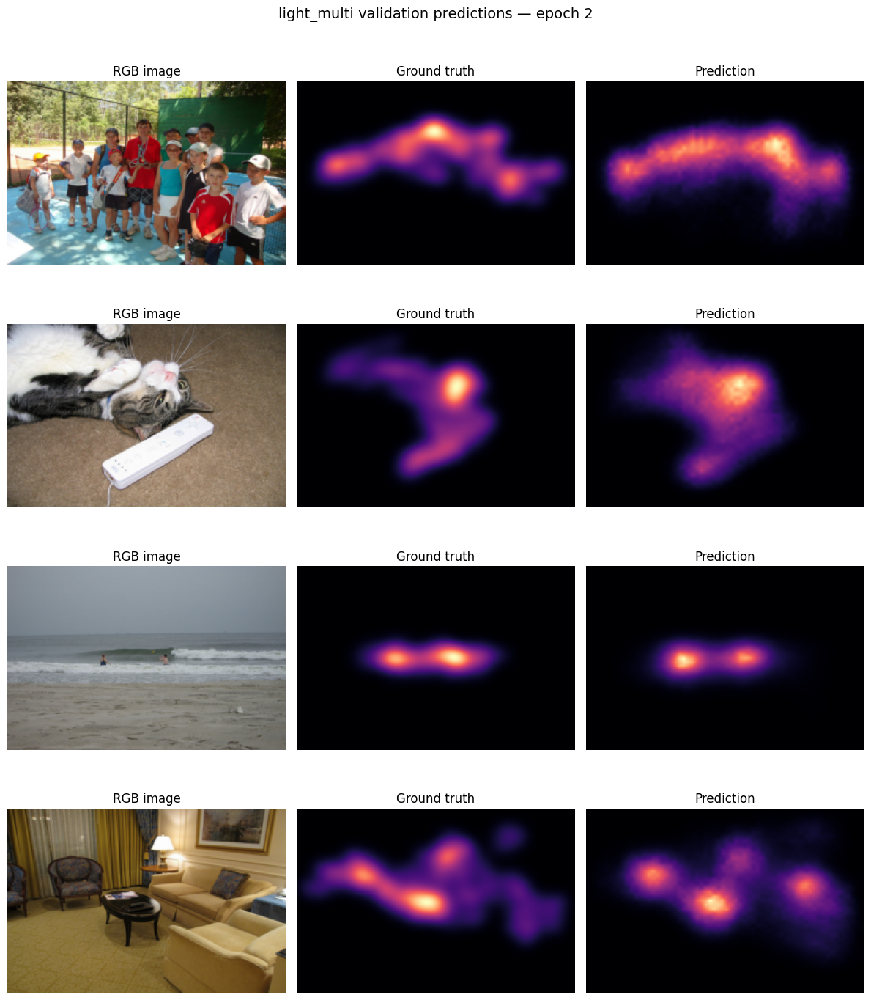


light_multi | epoch 3/3 | encoder: trainable | AMP: True
Train loss: 0.3069 | Val loss: 0.2993 | Val KLD: 0.2364 | Val CC: 0.8750 | Val SIM: 0.7673
Epoch time: 2.44 min | Best val CC: 0.8750 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


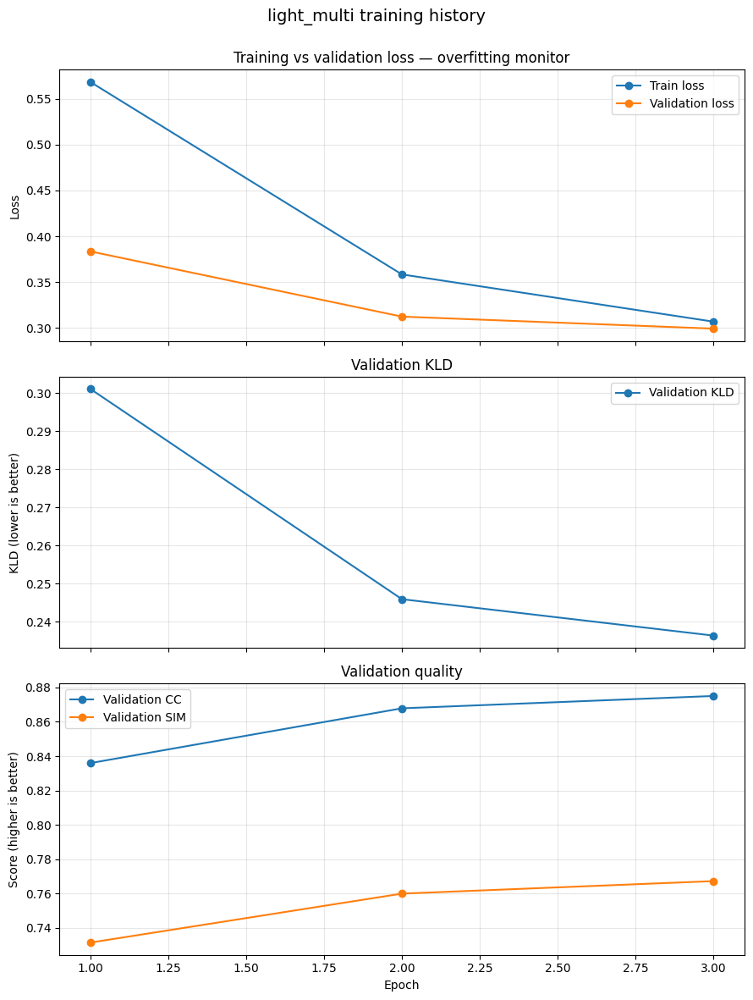

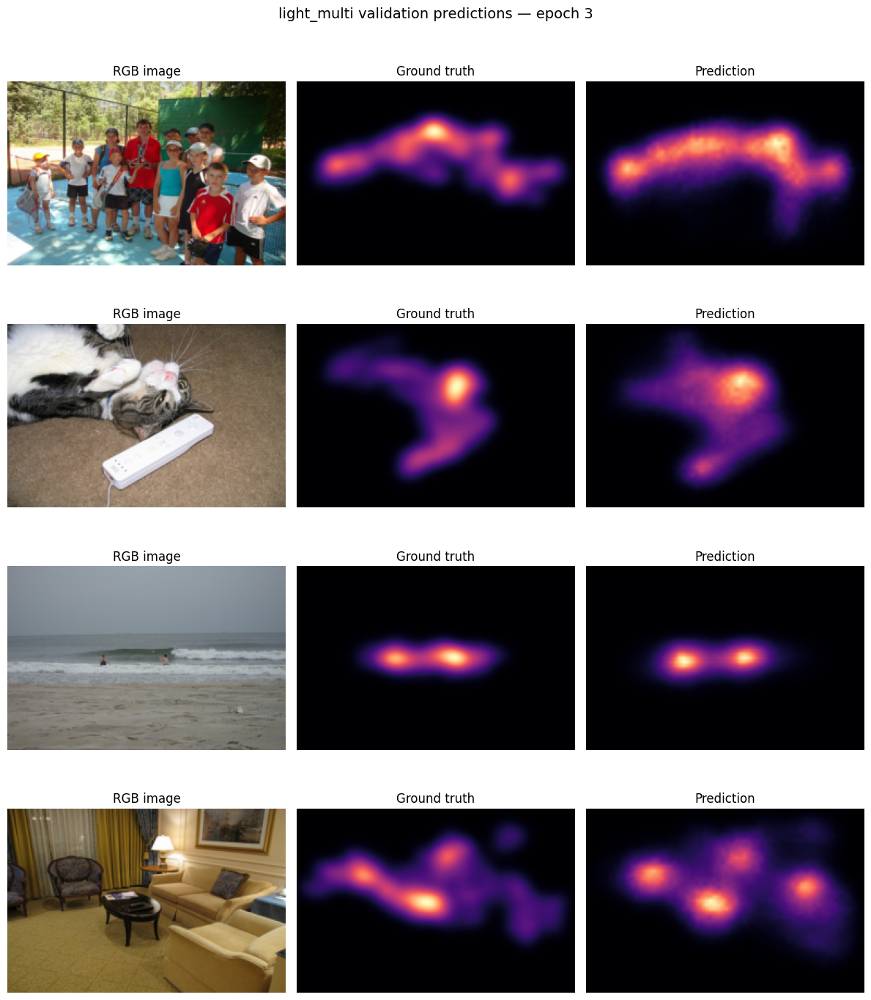


Training finished for light_multi. Best validation CC: 0.8750. Elapsed time: 7.52 minutes.
Best checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt


,epoch,train_loss,val_loss,val_kld,val_cc,val_sim,encoder_trainable,epoch_time_seconds
0,1,0.568310,0.383516,0.301066,0.835996,0.731534,False,140.242485
1,2,0.358407,0.312380,0.245904,0.867866,0.760020,True,149.485721
2,3,0.306897,0.299274,0.236351,0.875044,0.767285,True,146.602079


In [29]:
pilot_model, pilot_optimizer = create_light_multi_experiment()

pilot_resume_path = (
    LAST_CHECKPOINT_PATH
    if LAST_CHECKPOINT_PATH.is_file()
    else None
)

pilot_history = fit_model(
    model=pilot_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=pilot_optimizer,
    device=DEVICE,

    model_name=MODEL_NAME,
    epochs=PILOT_EPOCHS,

    checkpoint_dir=LIGHT_MULTI_CHECKPOINT_DIR,
    history_csv_path=LIGHT_MULTI_HISTORY_PATH,
    curves_figure_path=LIGHT_MULTI_CURVES_PATH,

    preview_batch=preview_batch,
    preview_figure_path=LIGHT_MULTI_PREVIEW_PATH,

    config=light_multi_config,
    split_seed=SEED,
    repo_root=REPO_ROOT,

    patience=EARLY_STOPPING_PATIENCE,
    min_delta=1e-4,

    freeze_encoder_epochs=1,
    freeze_encoder_batchnorm=True,

    use_amp=True,
    gradient_clip_norm=GRADIENT_CLIP_NORM,

    resume_from=pilot_resume_path,
    show_curves_each_epoch=True,
)

pilot_history_frame = pd.DataFrame(pilot_history)

display(
    pilot_history_frame[
        [
            "epoch",
            "train_loss",
            "val_loss",
            "val_kld",
            "val_cc",
            "val_sim",
            "encoder_trainable",
            "epoch_time_seconds",
        ]
    ]
)


## 30. Confirm pilot artifacts before final training

The final stage should not start unless both checkpoints, numerical history, curves, and the fixed preview exist.


In [30]:
pilot_outputs = {
    "best checkpoint": BEST_CHECKPOINT_PATH,
    "last checkpoint": LAST_CHECKPOINT_PATH,
    "history CSV": LIGHT_MULTI_HISTORY_PATH,
    "training curves": LIGHT_MULTI_CURVES_PATH,
    "validation preview": LIGHT_MULTI_PREVIEW_PATH,
}

missing_pilot_outputs = []
for label, path in pilot_outputs.items():
    exists = path.is_file()
    print(f"{label:22s} | {'OK' if exists else 'MISSING'} | {path}")
    if not exists:
        missing_pilot_outputs.append(label)

if missing_pilot_outputs:
    raise RuntimeError(
        f"Pilot stage is incomplete. Missing: {missing_pilot_outputs}"
    )


best checkpoint        | OK | /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
last checkpoint        | OK | /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
history CSV            | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv
training curves        | OK | /content/drive/MyDrive/saliency_project/outputs/figures/training_curves_light_multi.png
validation preview     | OK | /content/drive/MyDrive/saliency_project/outputs/figures/validation_preview_light_multi.png


## 31. Release the pilot model

Final training starts from a new architecture instance and restores the complete state from `last.pt`.


In [31]:
del pilot_model, pilot_optimizer

torch.cuda.empty_cache()


## 32. Resume final Light-M training

The target is at most 15 total epochs. Early stopping activates after three consecutive epochs without sufficient validation-CC improvement. Already completed epochs are not repeated.


Resumed light_multi from epoch 3. Next epoch: 4; best validation CC: 0.8750.

light_multi | epoch 4/15 | encoder: trainable | AMP: True
Train loss: 0.2763 | Val loss: 0.2889 | Val KLD: 0.2282 | Val CC: 0.8796 | Val SIM: 0.7708
Epoch time: 2.54 min | Best val CC: 0.8796 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


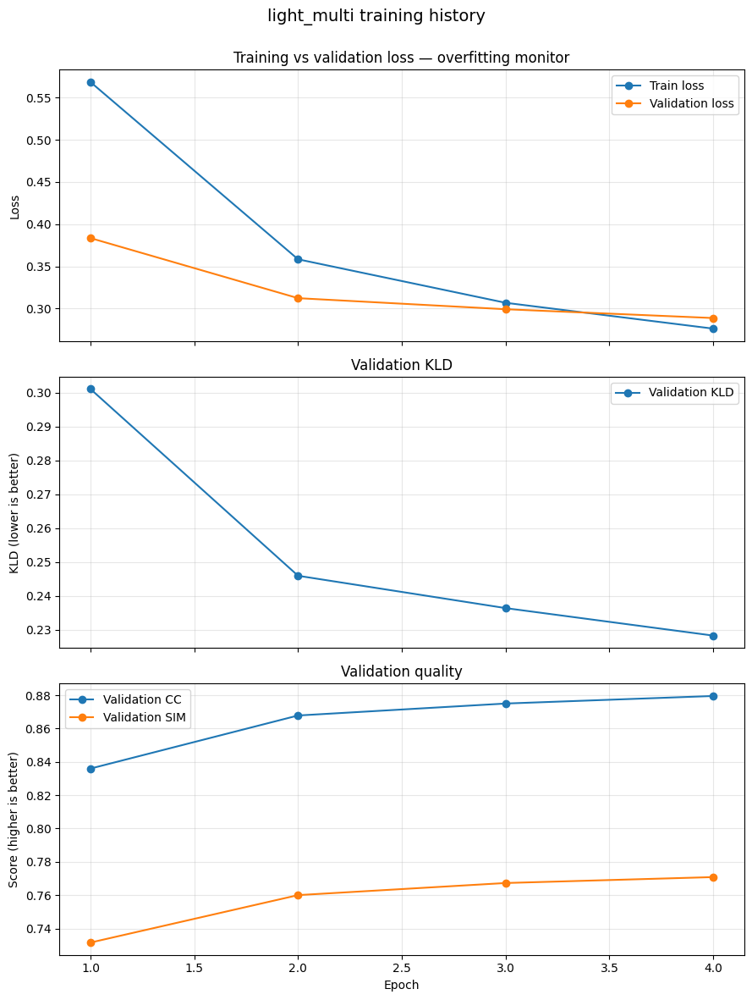

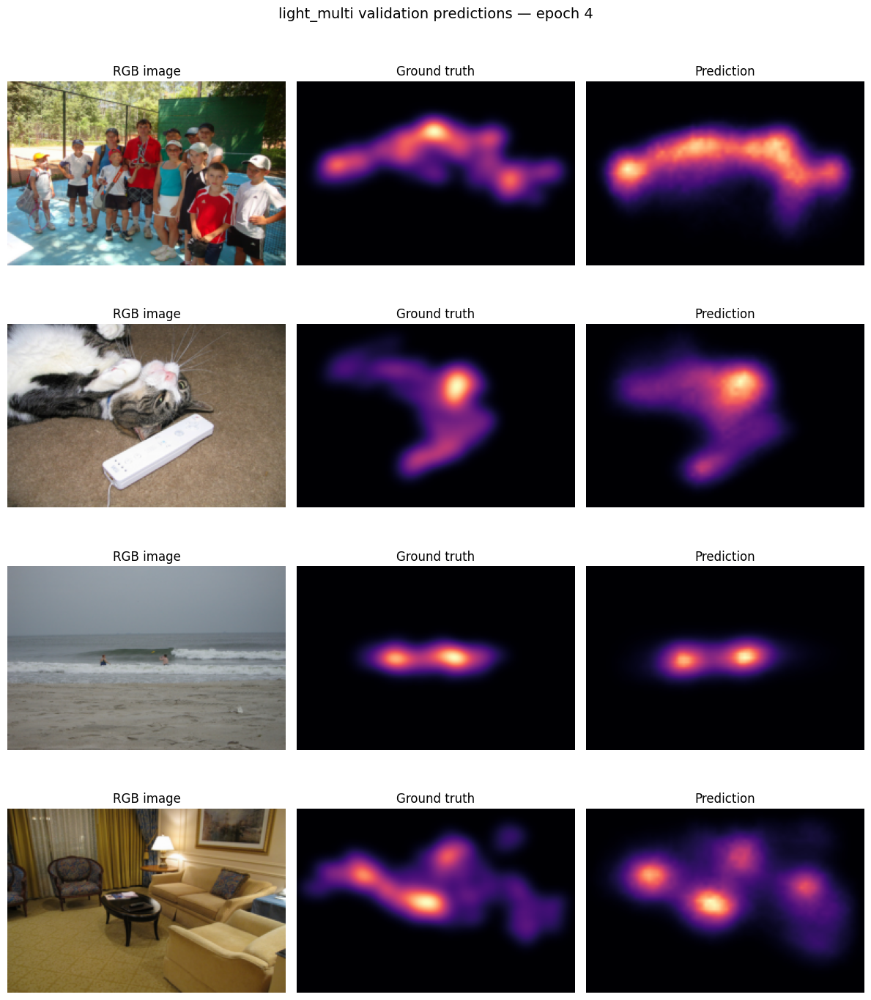


light_multi | epoch 5/15 | encoder: trainable | AMP: True
Train loss: 0.2510 | Val loss: 0.2873 | Val KLD: 0.2270 | Val CC: 0.8803 | Val SIM: 0.7723
Epoch time: 2.47 min | Best val CC: 0.8803 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


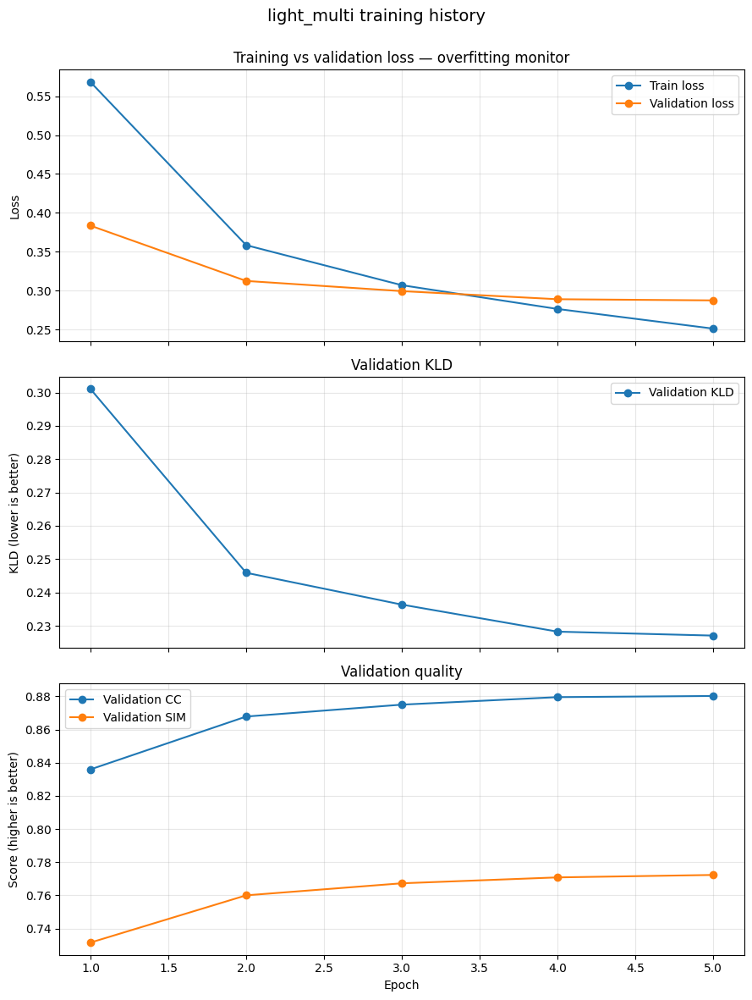

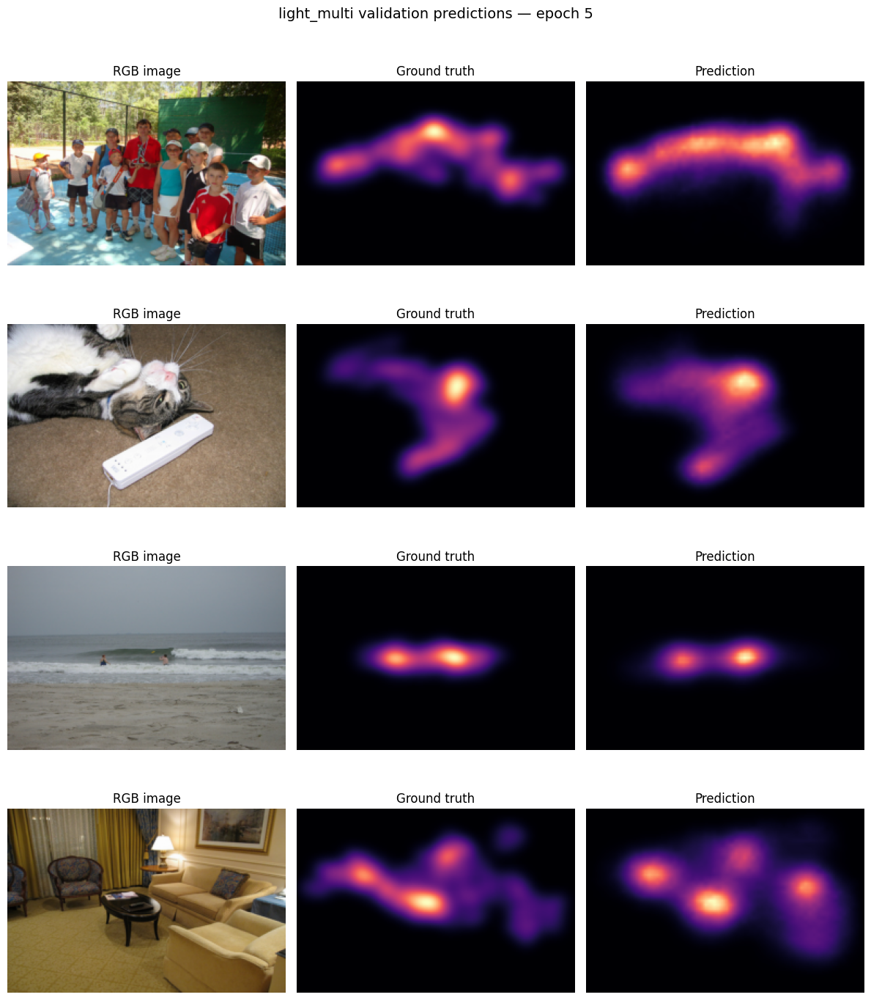


light_multi | epoch 6/15 | encoder: trainable | AMP: True
Train loss: 0.2295 | Val loss: 0.2847 | Val KLD: 0.2254 | Val CC: 0.8822 | Val SIM: 0.7732
Epoch time: 2.40 min | Best val CC: 0.8822 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


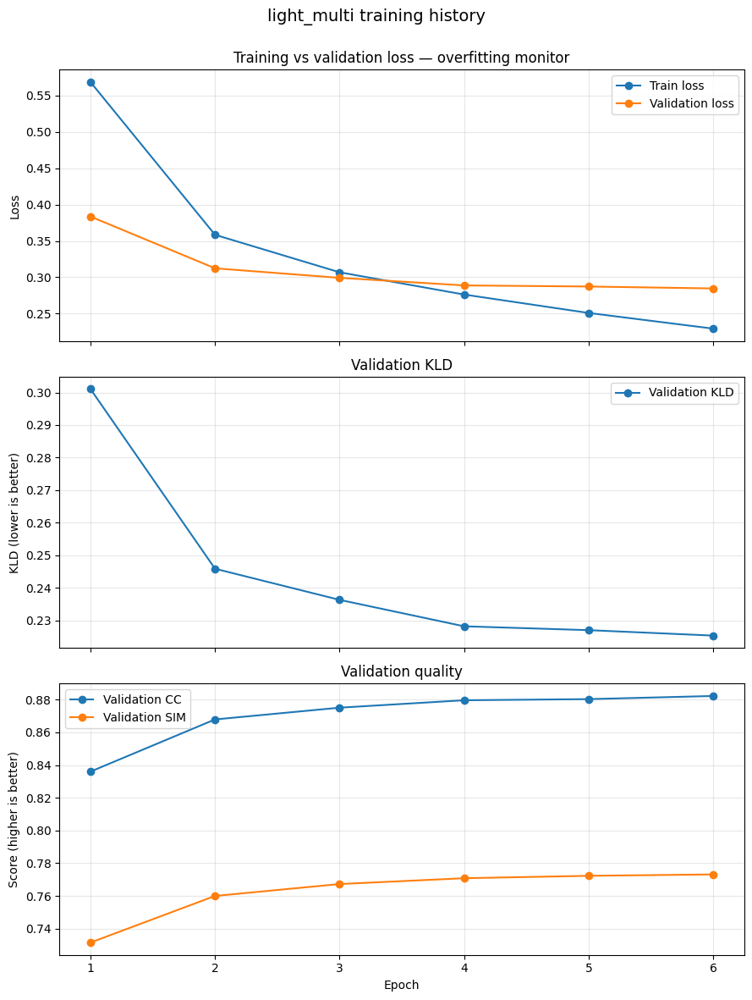

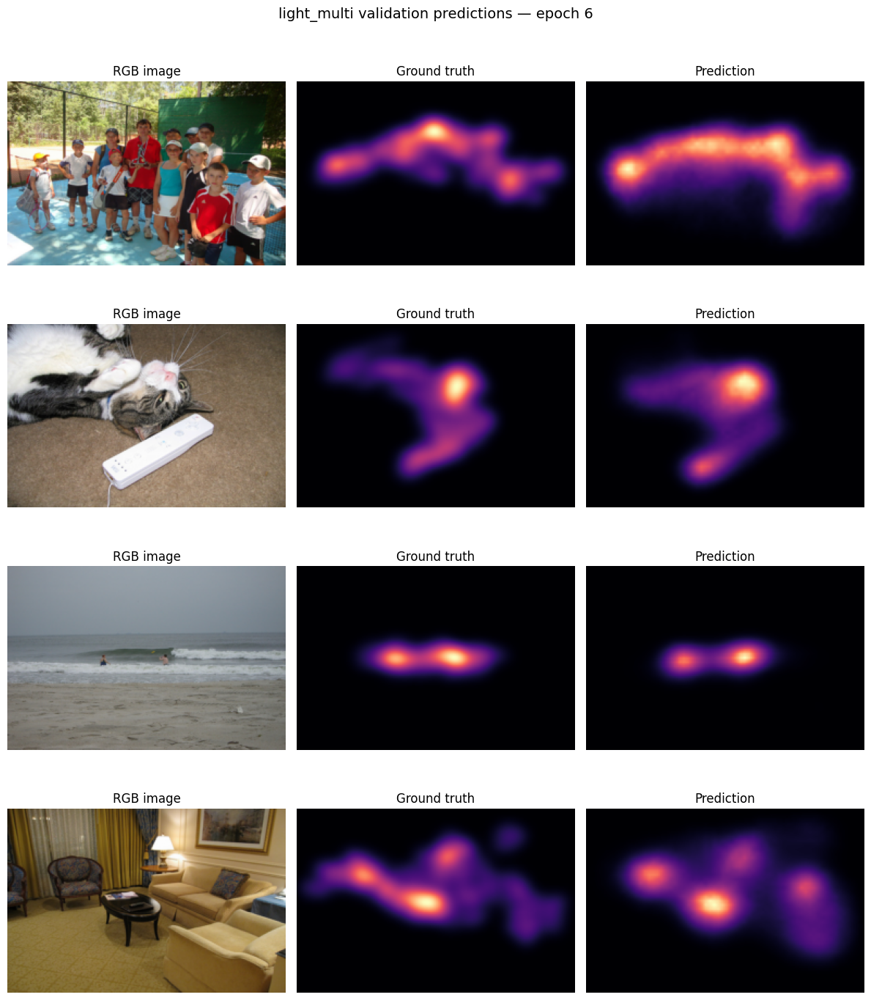


light_multi | epoch 7/15 | encoder: trainable | AMP: True
Train loss: 0.2098 | Val loss: 0.2971 | Val KLD: 0.2363 | Val CC: 0.8798 | Val SIM: 0.7740
Epoch time: 2.47 min | Best val CC: 0.8822 | No-improvement counter: 1/3
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


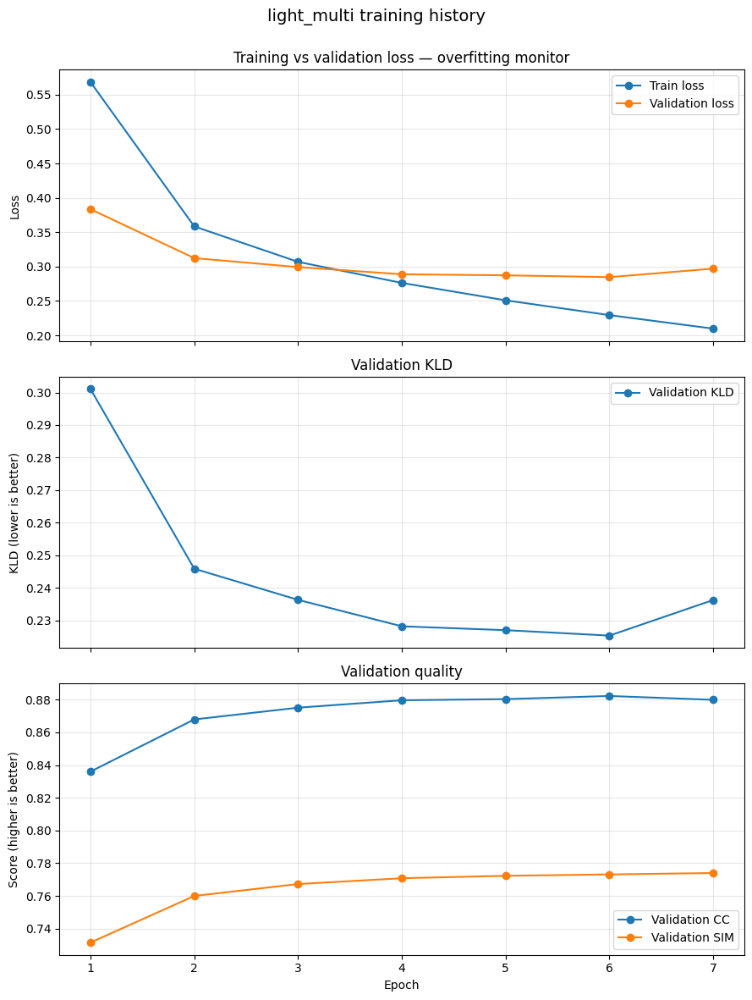

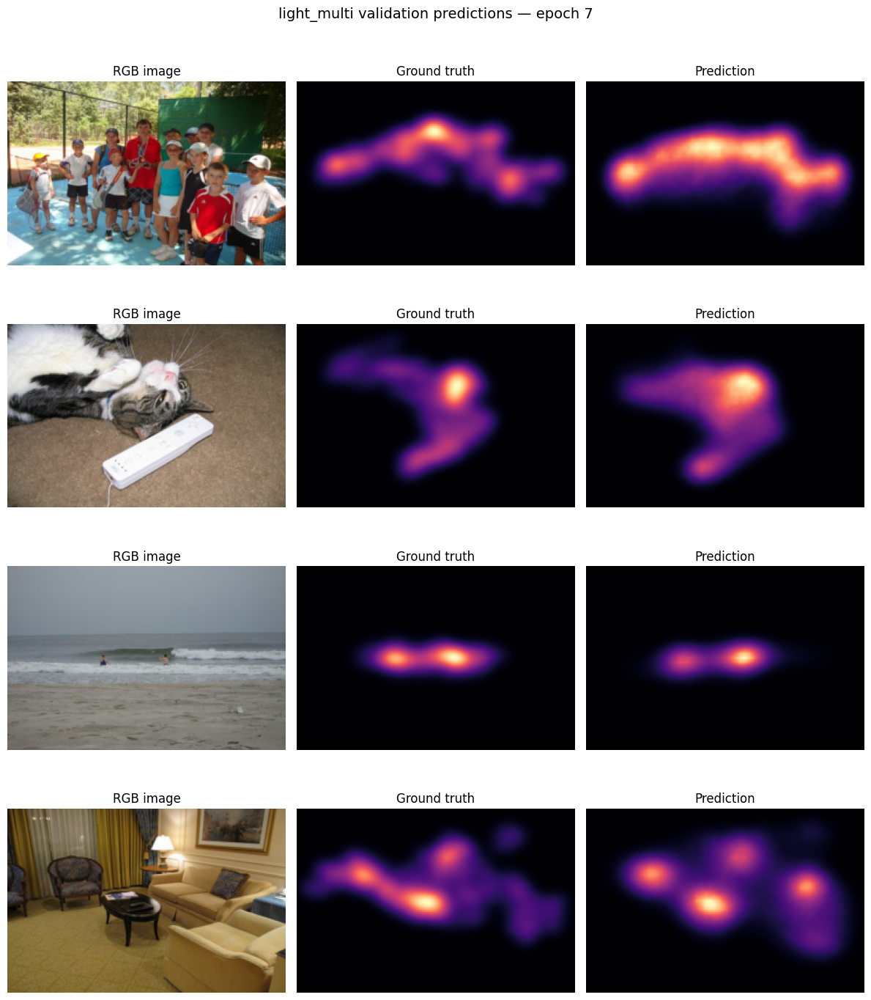


light_multi | epoch 8/15 | encoder: trainable | AMP: True
Train loss: 0.1928 | Val loss: 0.2931 | Val KLD: 0.2323 | Val CC: 0.8794 | Val SIM: 0.7727
Epoch time: 2.47 min | Best val CC: 0.8822 | No-improvement counter: 2/3
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


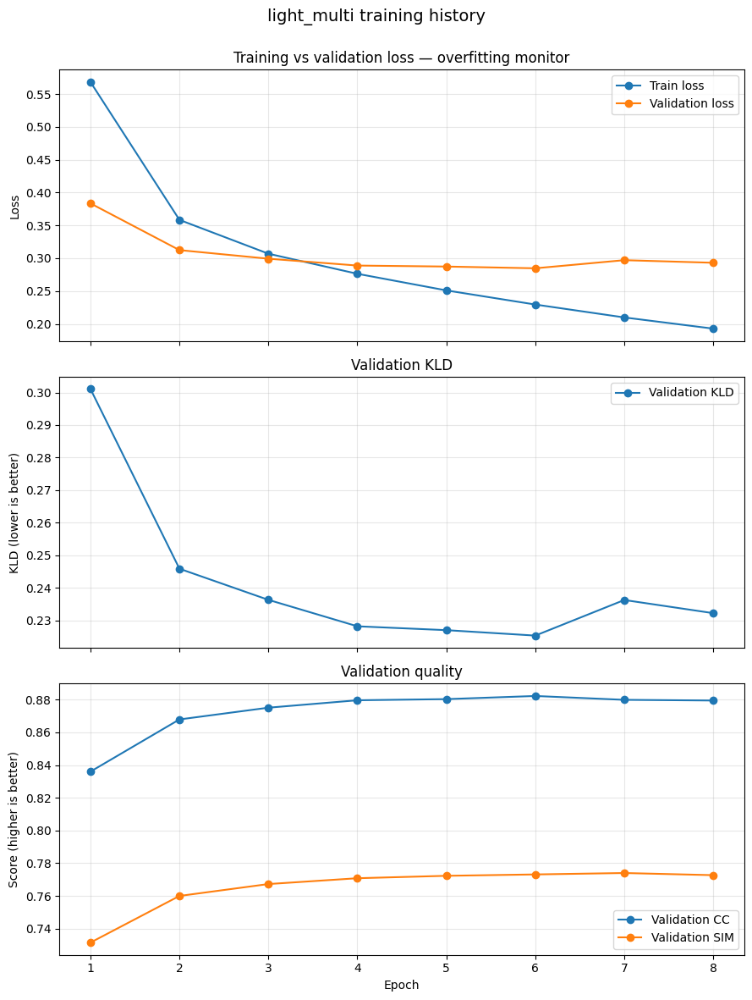

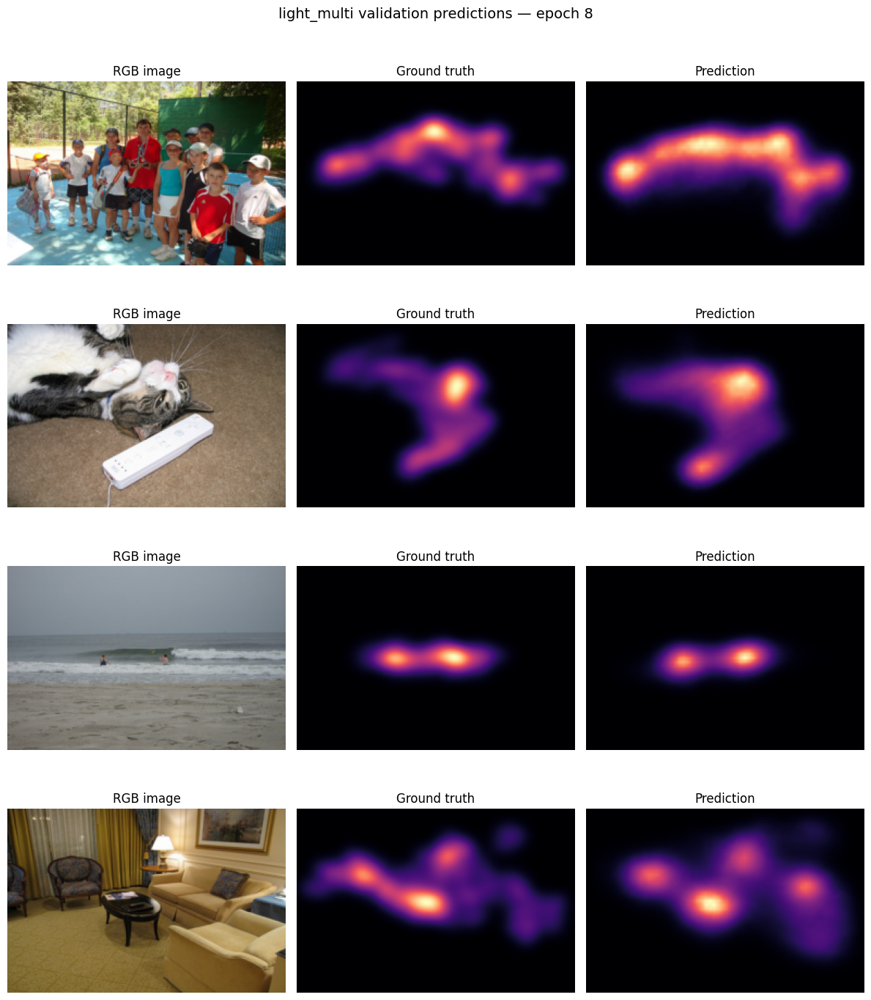


light_multi | epoch 9/15 | encoder: trainable | AMP: True
Train loss: 0.1784 | Val loss: 0.3012 | Val KLD: 0.2397 | Val CC: 0.8787 | Val SIM: 0.7745
Epoch time: 2.44 min | Best val CC: 0.8822 | No-improvement counter: 3/3
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv


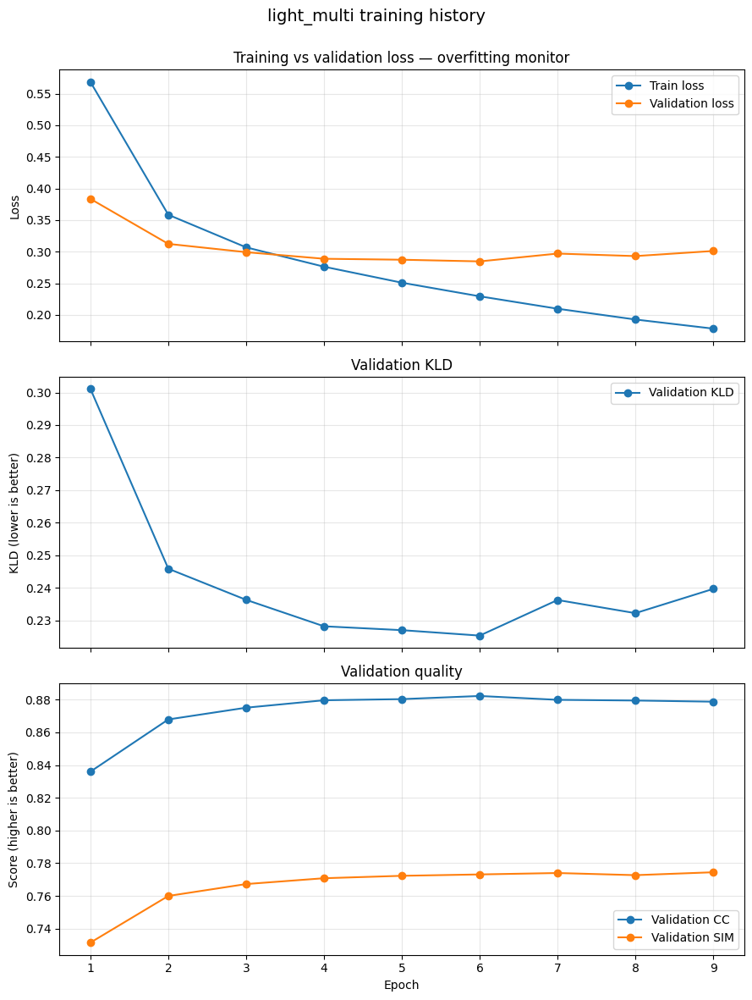

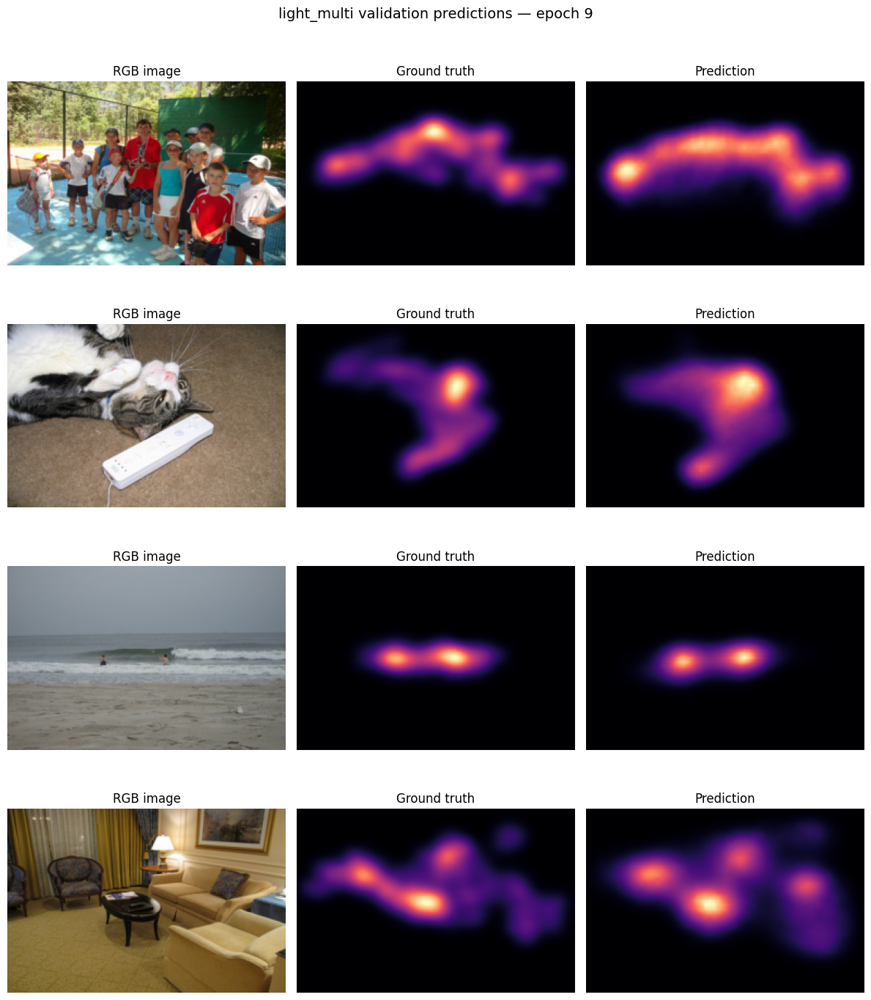

Early stopping: validation CC did not improve by at least 0.0001 for 3 consecutive epochs.

Training finished for light_multi. Best validation CC: 0.8822. Elapsed time: 15.30 minutes.
Best checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Last checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
Final training call completed.


In [32]:
final_model, final_optimizer = create_light_multi_experiment()

final_history = fit_model(
    model=final_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=final_optimizer,
    device=DEVICE,

    model_name=MODEL_NAME,
    epochs=MAX_EPOCHS,

    checkpoint_dir=LIGHT_MULTI_CHECKPOINT_DIR,
    history_csv_path=LIGHT_MULTI_HISTORY_PATH,
    curves_figure_path=LIGHT_MULTI_CURVES_PATH,

    preview_batch=preview_batch,
    preview_figure_path=LIGHT_MULTI_PREVIEW_PATH,

    config=light_multi_config,
    split_seed=SEED,
    repo_root=REPO_ROOT,

    patience=EARLY_STOPPING_PATIENCE,
    min_delta=1e-4,

    freeze_encoder_epochs=1,
    freeze_encoder_batchnorm=True,

    use_amp=True,
    gradient_clip_norm=GRADIENT_CLIP_NORM,

    resume_from=LAST_CHECKPOINT_PATH,
    show_curves_each_epoch=True,
)

print("Final training call completed.")


## 33. Inspect and save the complete epoch history

The key overfitting monitor is the joint view of training loss, validation loss, validation CC, and validation SIM across epochs.


,epoch,train_loss,val_loss,val_kld,val_cc,val_sim,encoder_trainable,epoch_time_seconds
0,1,0.568310,0.383516,0.301066,0.835996,0.731534,False,140.242485
1,2,0.358407,0.312380,0.245904,0.867866,0.760020,True,149.485721
2,3,0.306897,0.299274,0.236351,0.875044,0.767285,True,146.602079
3,4,0.276308,0.288852,0.228235,0.879579,0.770842,True,152.477500
4,5,0.251009,0.287338,0.227049,0.880272,0.772319,True,147.920855
5,6,0.229480,0.284694,0.225381,0.882194,0.773160,True,144.088928
6,7,0.209839,0.297055,0.236306,0.879842,0.774024,True,148.046788
7,8,0.192796,0.293090,0.232266,0.879422,0.772715,True,148.261464
8,9,0.178372,0.301164,0.239711,0.878709,0.774486,True,146.662711


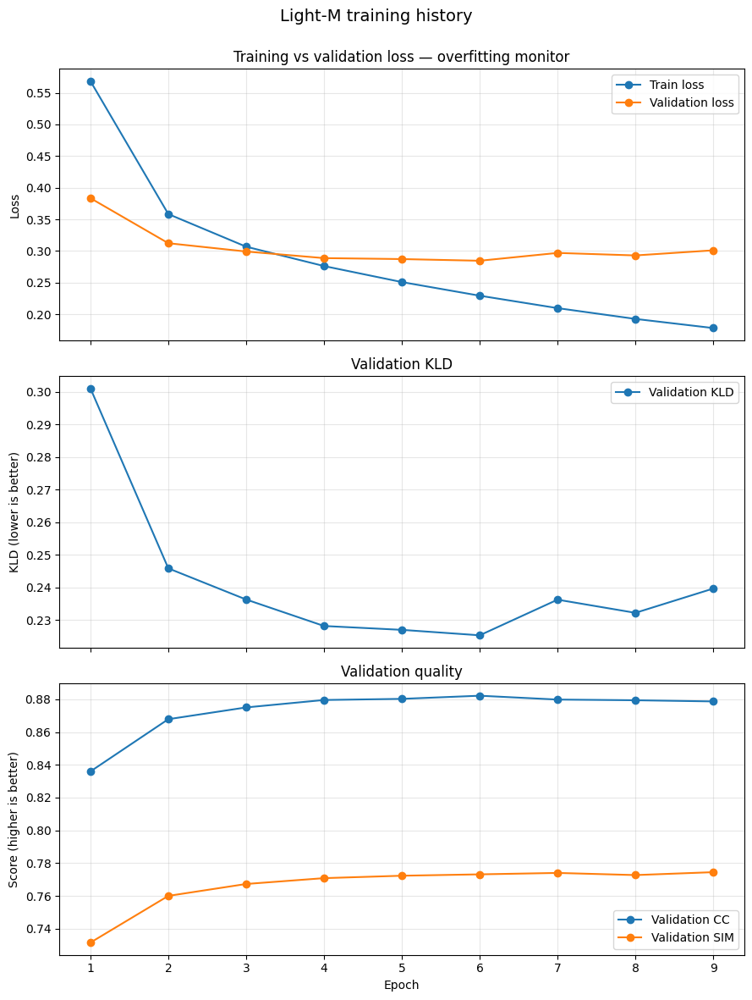

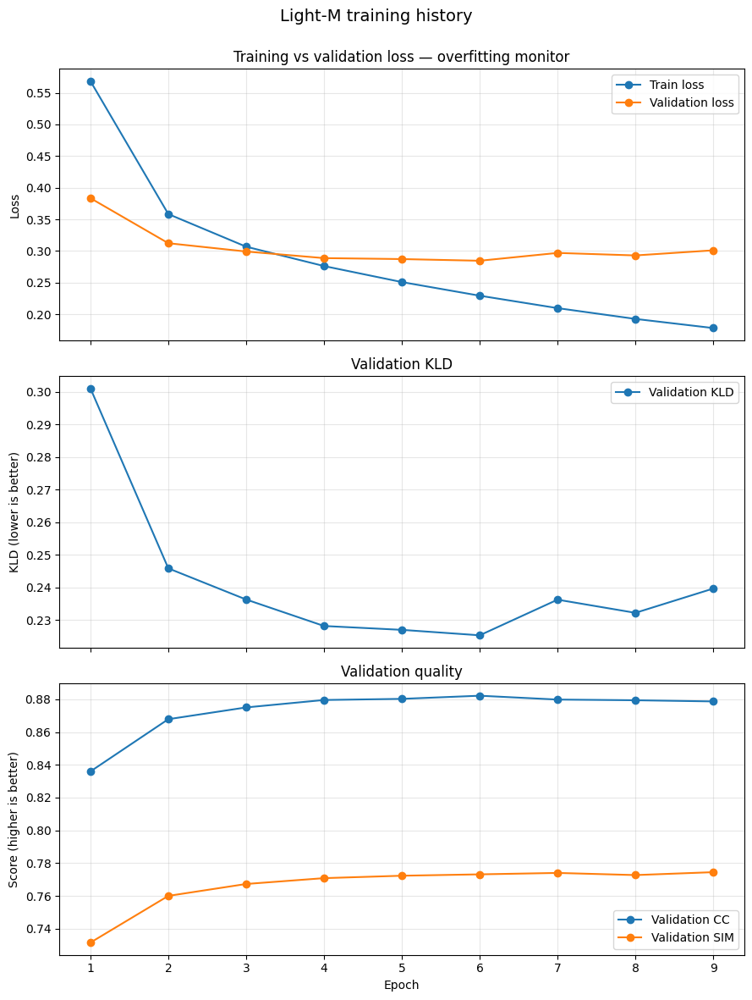

In [33]:
final_history_frame = pd.read_csv(LIGHT_MULTI_HISTORY_PATH)

required_history_columns = [
    "epoch",
    "train_loss",
    "val_loss",
    "val_kld",
    "val_cc",
    "val_sim",
    "encoder_trainable",
    "epoch_time_seconds",
]

missing_history_columns = [
    column for column in required_history_columns
    if column not in final_history_frame.columns
]

if missing_history_columns:
    raise ValueError(
        f"History CSV is missing columns: {missing_history_columns}"
    )

display(final_history_frame[required_history_columns])

plot_training_history(
    final_history_frame.to_dict("records"),
    output_path=LIGHT_MULTI_CURVES_PATH,
    show=True,
    title="Light-M training history",
)


## 34. Summarize convergence and possible overfitting

The best validation-CC epoch is recorded separately from the final epoch. A falling training loss with worsening validation loss or stagnant CC/SIM is evidence of overfitting.


In [34]:
best_history_index = final_history_frame["val_cc"].idxmax()
best_history_row = final_history_frame.loc[best_history_index]
last_history_row = final_history_frame.iloc[-1]

training_summary = {
    "model": MODEL_NAME,
    "completed_epochs": int(len(final_history_frame)),
    "best_epoch_by_val_cc": int(best_history_row["epoch"]),
    "best_val_cc": float(best_history_row["val_cc"]),
    "best_val_sim": float(best_history_row["val_sim"]),
    "best_val_kld": float(best_history_row["val_kld"]),
    "last_train_loss": float(last_history_row["train_loss"]),
    "last_val_loss": float(last_history_row["val_loss"]),
    "total_training_seconds": float(final_history_frame["epoch_time_seconds"].sum()),
}

pd.DataFrame([training_summary]).to_csv(
    LIGHT_MULTI_TRAINING_SUMMARY_PATH,
    index=False,
)

display(pd.DataFrame([training_summary]))
print("Saved training summary:", LIGHT_MULTI_TRAINING_SUMMARY_PATH)


,model,completed_epochs,best_epoch_by_val_cc,best_val_cc,best_val_sim,best_val_kld,last_train_loss,last_val_loss,total_training_seconds
0,light_multi,9,6,0.882194,0.77316,0.225381,0.178372,0.301164,1323.788531


Saved training summary: /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_training_summary.csv


## 35. Release the final training state

The best-checkpoint evaluation uses a fresh model. Releasing the final model and optimizer keeps GPU memory usage predictable.


In [35]:
del final_model, final_optimizer

torch.cuda.empty_cache()


## 36. Load the best Light-M checkpoint

Validation is recomputed from the checkpoint selected during training, not from whichever model state happens to remain in notebook memory.


In [36]:
best_model = build_model(
    MODEL_NAME,
    pretrained=False,
    decoder_channels=DECODER_CHANNELS,
).to(DEVICE)

best_checkpoint = load_checkpoint(
    BEST_CHECKPOINT_PATH,
    model=best_model,
    device=DEVICE,
)

print("Best epoch:        ", best_checkpoint["epoch"])
print("Stored best val CC:", best_checkpoint["best_val_cc"])


Best epoch:         6
Stored best val CC: 0.8821937543869018


## 37. Recompute and save best-checkpoint validation metrics

The dataset-level summary and one row per validation image are both saved. Per-image CC values are needed later for median, worst-case, and off-centre qualitative selection.


In [37]:
validation_summary, validation_per_image = evaluate_model(
    best_model,
    val_loader,
    DEVICE,
    use_amp=True,
    return_per_image=True,
)

validation_summary_row = {
    "model": MODEL_NAME,
    "split": "validation",
    "checkpoint_epoch": int(best_checkpoint["epoch"]),
    **validation_summary,
}

pd.DataFrame([validation_summary_row]).to_csv(
    LIGHT_MULTI_VAL_SUMMARY_PATH,
    index=False,
)

validation_per_image_frame = pd.DataFrame(validation_per_image)
validation_per_image_frame.insert(0, "model", MODEL_NAME)
validation_per_image_frame.insert(1, "split", "validation")
validation_per_image_frame.to_csv(
    LIGHT_MULTI_VAL_PER_IMAGE_PATH,
    index=False,
)

display(pd.DataFrame([validation_summary_row]))
print("Saved validation summary:  ", LIGHT_MULTI_VAL_SUMMARY_PATH)
print("Saved per-image metrics:   ", LIGHT_MULTI_VAL_PER_IMAGE_PATH)


,model,split,checkpoint_epoch,loss,kld,cc,sim,num_samples,num_batches,duration_seconds
0,light_multi,validation,6,0.284694,0.225381,0.882194,0.77316,2500.0,313.0,28.064611


Saved validation summary:   /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_validation_summary.csv
Saved per-image metrics:    /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_validation_per_image.csv


## 38. Save the best-checkpoint validation preview

The shared visualization function is applied after loading `best.pt`, so this file is guaranteed to represent the selected checkpoint.


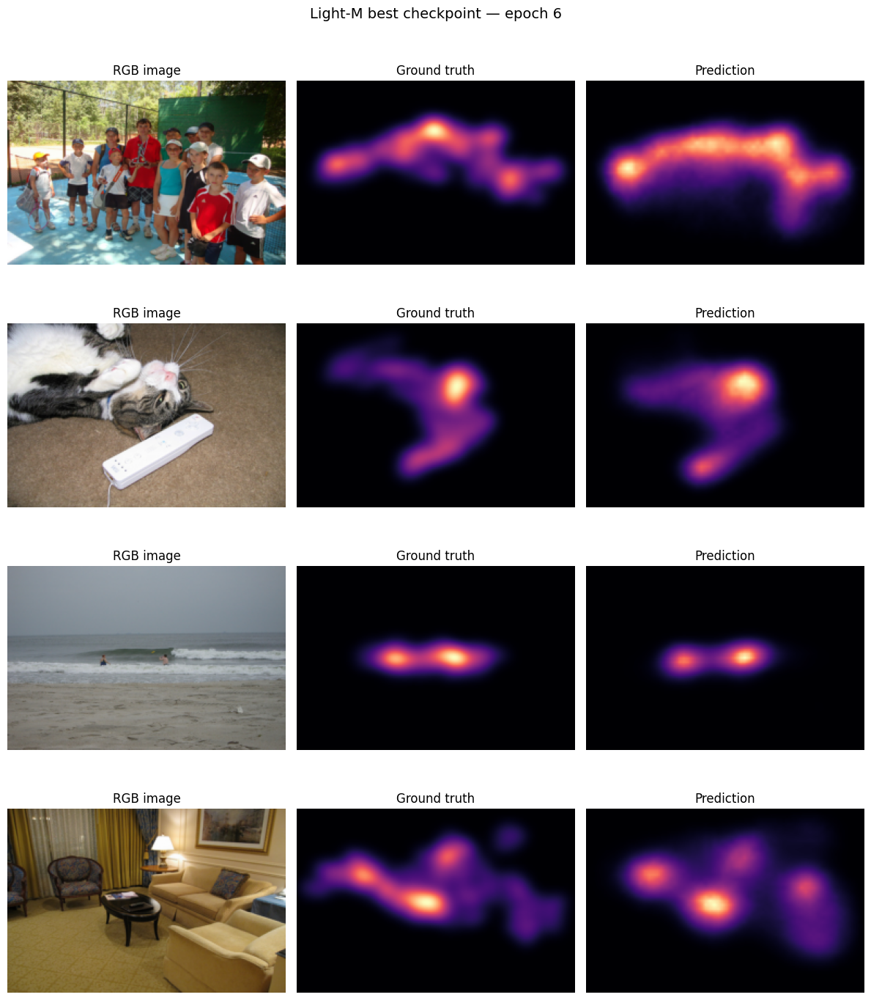

Saved best-checkpoint preview: /content/drive/MyDrive/saliency_project/outputs/figures/best_validation_preview_light_multi.png


In [38]:
plot_prediction_panel(
    best_model,
    preview_batch,
    DEVICE,
    output_path=LIGHT_MULTI_BEST_PREVIEW_PATH,
    max_samples=4,
    use_amp=True,
    title=f"Light-M best checkpoint — epoch {best_checkpoint['epoch']}",
)

print("Saved best-checkpoint preview:", LIGHT_MULTI_BEST_PREVIEW_PATH)


## 39. Compare Light-S and Light-M on validation when Light-S files exist

This is a development comparison only. The final reportable comparison must later be recomputed on the frozen internal test split in `06_final_evaluation.ipynb`.


In [39]:
LIGHT_SINGLE_HISTORY_PATH = METRICS_ROOT / "light_single_history.csv"
LIGHT_SINGLE_VAL_SUMMARY_PATH = METRICS_ROOT / "light_single_validation_summary.csv"

if LIGHT_SINGLE_VAL_SUMMARY_PATH.is_file():
    light_single_summary = pd.read_csv(LIGHT_SINGLE_VAL_SUMMARY_PATH).iloc[0].to_dict()
    light_multi_summary = pd.read_csv(LIGHT_MULTI_VAL_SUMMARY_PATH).iloc[0].to_dict()

    comparison_rows = []
    for summary in [light_single_summary, light_multi_summary]:
        comparison_rows.append(
            {
                "model": summary.get("model"),
                "loss": summary.get("loss"),
                "kld": summary.get("kld"),
                "cc": summary.get("cc"),
                "sim": summary.get("sim"),
                "checkpoint_epoch": summary.get("checkpoint_epoch"),
            }
        )

    light_comparison_frame = pd.DataFrame(comparison_rows)
    light_comparison_frame.to_csv(LIGHT_COMPARISON_CSV_PATH, index=False)

    display(light_comparison_frame)
    print("Saved validation comparison:", LIGHT_COMPARISON_CSV_PATH)
else:
    print(
        "Light-S validation summary was not found; numerical comparison skipped.\n"
        f"Expected: {LIGHT_SINGLE_VAL_SUMMARY_PATH}"
    )


Light-S validation summary was not found; numerical comparison skipped.
Expected: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_validation_summary.csv


## 40. Plot Light-S and Light-M validation history when both histories exist

The figure makes the effect of multi-scale fusion visible across epochs rather than comparing only one selected checkpoint.


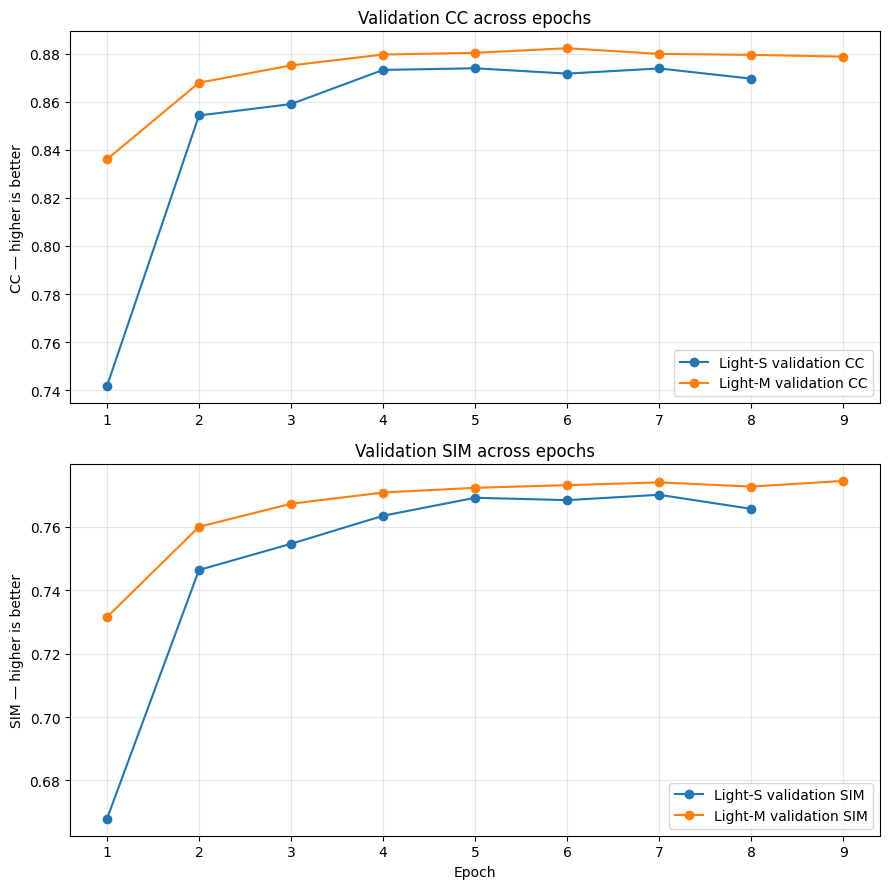

Saved history comparison: /content/drive/MyDrive/saliency_project/outputs/figures/light_single_vs_light_multi_history.png


In [40]:
if LIGHT_SINGLE_HISTORY_PATH.is_file() and LIGHT_MULTI_HISTORY_PATH.is_file():
    light_single_history = pd.read_csv(LIGHT_SINGLE_HISTORY_PATH)
    light_multi_history = pd.read_csv(LIGHT_MULTI_HISTORY_PATH)

    figure, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=False)

    axes[0].plot(
        light_single_history["epoch"],
        light_single_history["val_cc"],
        marker="o",
        label="Light-S validation CC",
    )
    axes[0].plot(
        light_multi_history["epoch"],
        light_multi_history["val_cc"],
        marker="o",
        label="Light-M validation CC",
    )
    axes[0].set_ylabel("CC — higher is better")
    axes[0].set_title("Validation CC across epochs")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        light_single_history["epoch"],
        light_single_history["val_sim"],
        marker="o",
        label="Light-S validation SIM",
    )
    axes[1].plot(
        light_multi_history["epoch"],
        light_multi_history["val_sim"],
        marker="o",
        label="Light-M validation SIM",
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("SIM — higher is better")
    axes[1].set_title("Validation SIM across epochs")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    figure.tight_layout()
    figure.savefig(LIGHT_COMPARISON_FIGURE_PATH, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(figure)

    print("Saved history comparison:", LIGHT_COMPARISON_FIGURE_PATH)
else:
    print("Both Light-S and Light-M history CSV files are required for this plot.")


## 41. Record the environment and completed run

The JSON environment record and Markdown run note make the experiment reconstructable after the Colab session ends.


In [41]:
commit_result = subprocess.run(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"],
    capture_output=True,
    text=True,
)

git_commit = (
    commit_result.stdout.strip()
    if commit_result.returncode == 0
    else None
)

environment_record = {
    "model": MODEL_NAME,
    "git_commit": git_commit,
    "pytorch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
    "seed": SEED,
    "output_size": list(OUTPUT_SIZE),
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "local_image_files": image_file_count,
    "local_map_files": map_file_count,
    "best_epoch": int(best_checkpoint["epoch"]),
    "best_validation_cc": float(best_checkpoint["best_val_cc"]),
}

LIGHT_MULTI_ENVIRONMENT_PATH = LOG_ROOT / "light_multi_environment.json"
with LIGHT_MULTI_ENVIRONMENT_PATH.open("w", encoding="utf-8") as file:
    json.dump(environment_record, file, indent=2)

run_timestamp = time.strftime("%Y-%m-%d %H:%M:%S")
run_note_path = LOG_ROOT / "run_notes" / "light_multi_latest.md"
run_note_path.write_text(
    "\n".join(
        [
            f"# Light-M training — {run_timestamp}",
            "",
            f"- Git commit: `{git_commit}`",
            f"- Completed epochs: {len(final_history_frame)}",
            f"- Best epoch: {best_checkpoint['epoch']}",
            f"- Best validation CC: {best_checkpoint['best_val_cc']:.6f}",
            f"- Checkpoint directory: `{LIGHT_MULTI_CHECKPOINT_DIR}`",
            f"- History CSV: `{LIGHT_MULTI_HISTORY_PATH}`",
            f"- Curves: `{LIGHT_MULTI_CURVES_PATH}`",
            f"- Validation summary: `{LIGHT_MULTI_VAL_SUMMARY_PATH}`",
            "- Next stage: `05_heavy_multi.ipynb`",
        ]
    ),
    encoding="utf-8",
)

print("Saved environment:", LIGHT_MULTI_ENVIRONMENT_PATH)
print("Saved run note:   ", run_note_path)


Saved environment: /content/drive/MyDrive/saliency_project/logs/light_multi_environment.json
Saved run note:    /content/drive/MyDrive/saliency_project/logs/run_notes/light_multi_latest.md


## 42. Final Light-M artifact checklist

Every required training artifact must exist in Drive before the runtime is closed.


In [42]:
required_outputs = {
    "best checkpoint": BEST_CHECKPOINT_PATH,
    "last checkpoint": LAST_CHECKPOINT_PATH,
    "experiment config": LIGHT_MULTI_CONFIG_PATH,
    "epoch history": LIGHT_MULTI_HISTORY_PATH,
    "training summary": LIGHT_MULTI_TRAINING_SUMMARY_PATH,
    "training curves": LIGHT_MULTI_CURVES_PATH,
    "latest epoch preview": LIGHT_MULTI_PREVIEW_PATH,
    "best checkpoint preview": LIGHT_MULTI_BEST_PREVIEW_PATH,
    "validation summary": LIGHT_MULTI_VAL_SUMMARY_PATH,
    "validation per-image metrics": LIGHT_MULTI_VAL_PER_IMAGE_PATH,
    "environment record": LIGHT_MULTI_ENVIRONMENT_PATH,
}

if RUN_TINY_OVERFIT:
    required_outputs["tiny-overfit figure"] = LIGHT_MULTI_TINY_OVERFIT_PATH

missing_outputs = []

for label, path in required_outputs.items():
    exists = path.is_file()
    print(f"{label:32s} | {'OK' if exists else 'MISSING'} | {path}")
    if not exists:
        missing_outputs.append(label)

if missing_outputs:
    raise RuntimeError(
        f"Light-M training stage is incomplete. Missing: {missing_outputs}"
    )

print("\nLight-M training stage completed successfully.")


best checkpoint                  | OK | /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
last checkpoint                  | OK | /content/drive/MyDrive/saliency_project/checkpoints/light_multi/last.pt
experiment config                | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_config.json
epoch history                    | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_history.csv
training summary                 | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/light_multi_training_summary.csv
training curves                  | OK | /content/drive/MyDrive/saliency_project/outputs/figures/training_curves_light_multi.png
latest epoch preview             | OK | /content/drive/MyDrive/saliency_project/outputs/figures/validation_preview_light_multi.png
best checkpoint preview          | OK | /content/drive/MyDrive/saliency_project/outputs/figures/best_validation_preview_light_multi.png
validation s

## Next project stage

Create `05_heavy_multi.ipynb` and keep the same:

- local SALICON cache;
- fixed manifests and preprocessing;
- output size;
- decoder width;
- loss and metrics;
- optimizer policy;
- epoch budget;
- validation-CC checkpoint rule;
- epoch-by-epoch overfitting curves.

The Heavy-M notebook changes only the encoder from MobileNetV2 to ResNet-18 while reusing the same multi-scale decoder design.
